In [1]:
from google.colab import files

uploaded = files.upload()

Saving AI_Smart_Healthcare_Early_Diagnosis_v0_1 (1).zip to AI_Smart_Healthcare_Early_Diagnosis_v0_1 (1).zip


In [18]:
!unzip -q "AI_Smart_Healthcare_Early_Diagnosis_v0_1 (1).zip"

In [19]:
!ls

 AI_Smart_Healthcare_Early_Diagnosis		     sample_data
'AI_Smart_Healthcare_Early_Diagnosis_v0_1 (1).zip'


In [20]:
%cd AI_Smart_Healthcare_Early_Diagnosis

/content/AI_Smart_Healthcare_Early_Diagnosis


In [21]:
!find . -maxdepth 2 -type f

./research_protocol.md
./data/README.md
./.gitignore
./literature_matrix.csv
./requirements.txt
./paper_outline.md
./models/.gitkeep
./README.md
./app/app.py
./src/__init__.py
./src/models.py
./src/preprocessing.py
./src/metrics.py
./src/explain.py
./src/data_loader.py
./src/train.py


In [22]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 52.9 MB/s eta 0:00:00


In [23]:
import pandas
import sklearn
import xgboost
import catboost
import shap

print("✅ All required libraries installed successfully!")

✅ All required libraries installed successfully!


In [24]:
from src.data_loader import load_data

df = load_data()

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (520, 17)

Columns:
['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity', 'class']


In [25]:
df.head()

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   age                 520 non-null    int64 
 1   gender              520 non-null    object
 2   polyuria            520 non-null    object
 3   polydipsia          520 non-null    object
 4   sudden_weight_loss  520 non-null    object
 5   weakness            520 non-null    object
 6   polyphagia          520 non-null    object
 7   genital_thrush      520 non-null    object
 8   visual_blurring     520 non-null    object
 9   itching             520 non-null    object
 10  irritability        520 non-null    object
 11  delayed_healing     520 non-null    object
 12  partial_paresis     520 non-null    object
 13  muscle_stiffness    520 non-null    object
 14  alopecia            520 non-null    object
 15  obesity             520 non-null    object
 16  class               520 no

In [27]:
print(df["class"].value_counts())
print("\nPercentages:")
print(df["class"].value_counts(normalize=True) * 100)

class
Positive    320
Negative    200
Name: count, dtype: int64

Percentages:
class
Positive    61.538462
Negative    38.461538
Name: proportion, dtype: float64


In [28]:
missing = df.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [29]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,520.0,NaN,NaN,NaN,48.028846,12.151466,16.0,39.0,47.5,57.0,90.0
gender,520,2,Male,328,NaN,NaN,NaN,NaN,NaN,NaN,NaN
polyuria,520,2,No,262,NaN,NaN,NaN,NaN,NaN,NaN,NaN
polydipsia,520,2,No,287,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sudden_weight_loss,520,2,No,303,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weakness,520,2,Yes,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
polyphagia,520,2,No,283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genital_thrush,520,2,No,404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visual_blurring,520,2,No,287,NaN,NaN,NaN,NaN,NaN,NaN,NaN
itching,520,2,No,267,NaN,NaN,NaN,NaN,NaN,NaN,NaN


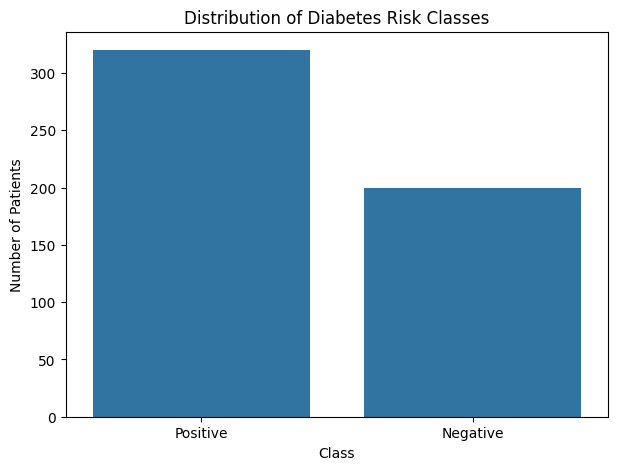

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="class")
plt.title("Distribution of Diabetes Risk Classes")
plt.xlabel("Class")
plt.ylabel("Number of Patients")
plt.show()

In [31]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity', 'class']


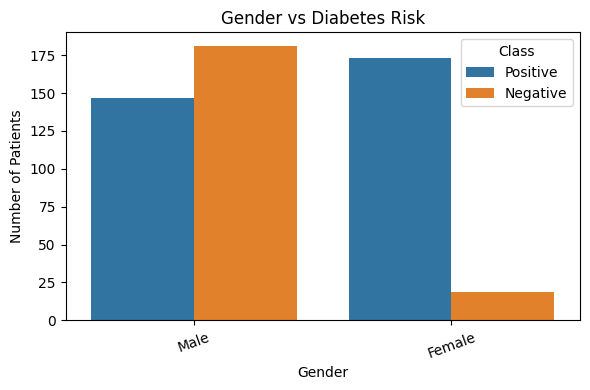

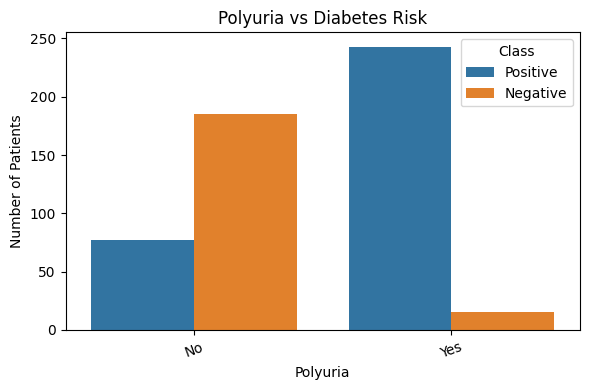

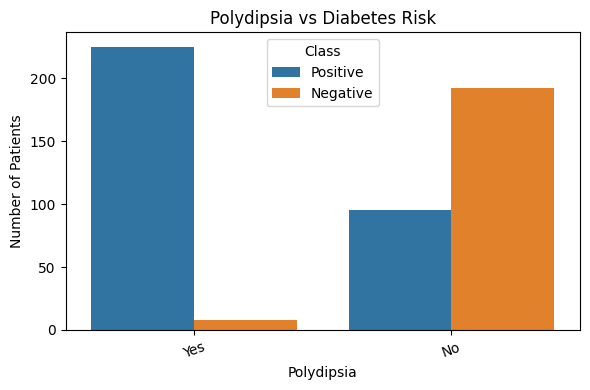

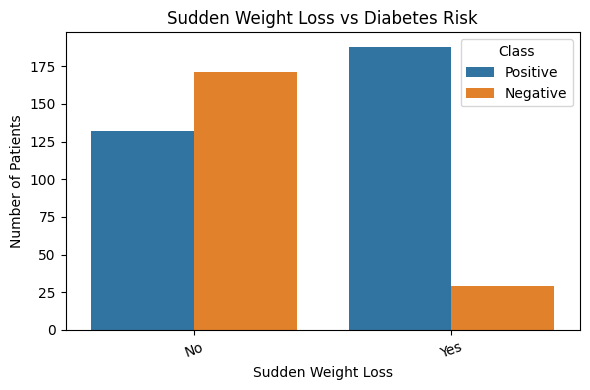

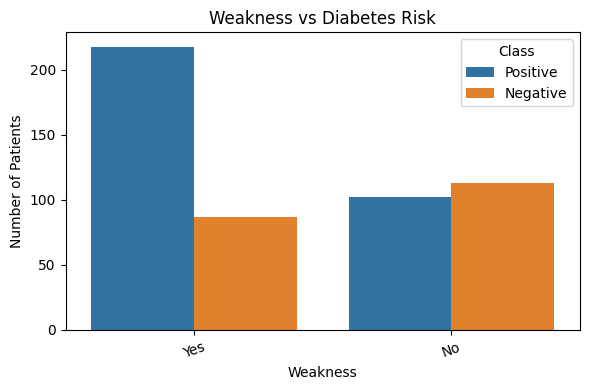

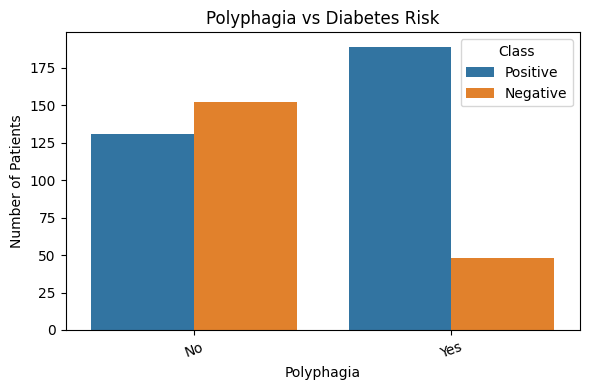

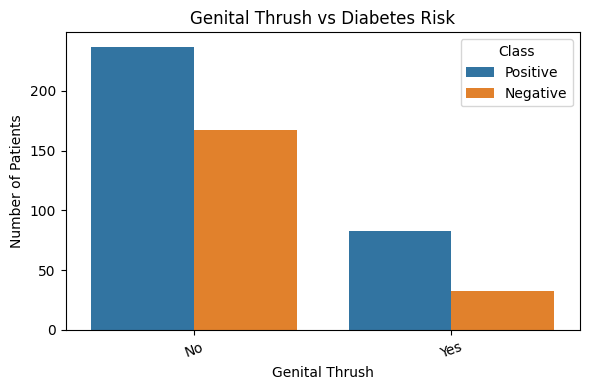

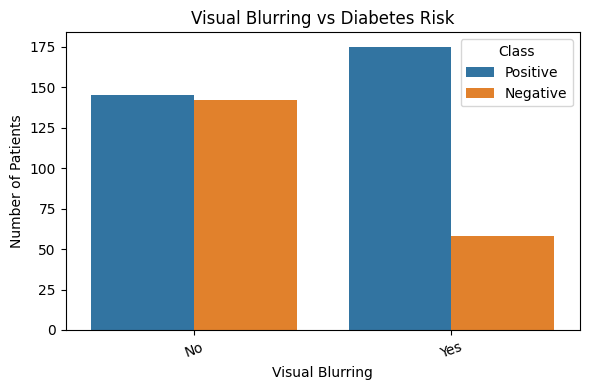

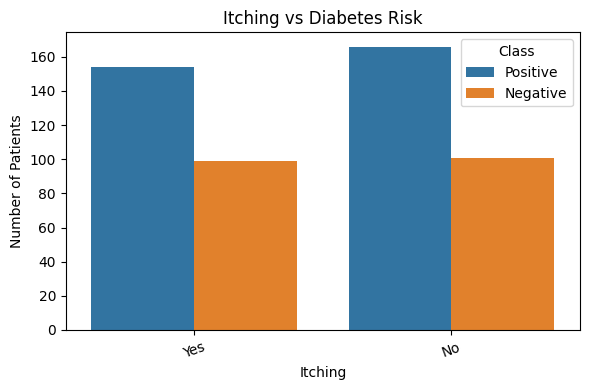

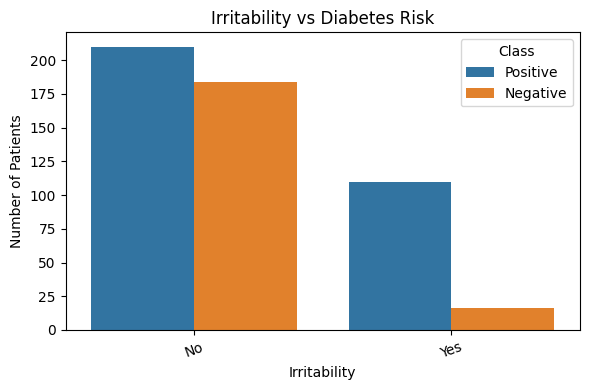

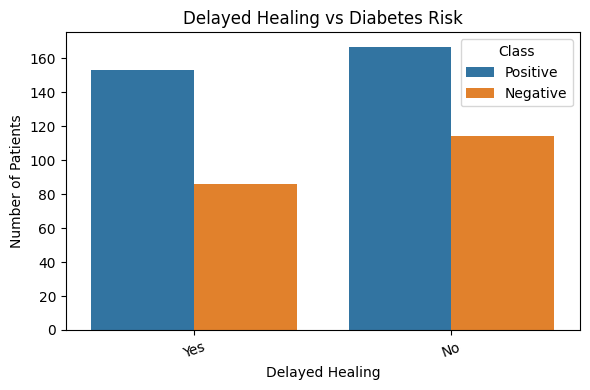

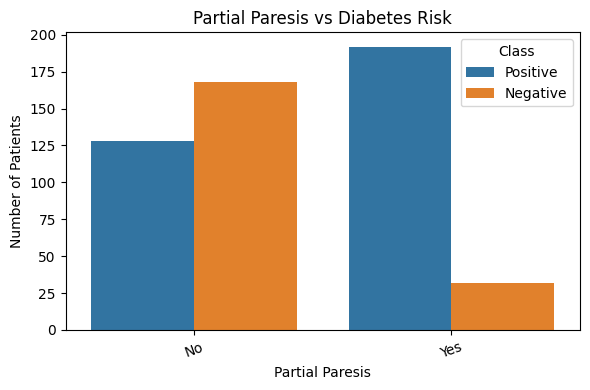

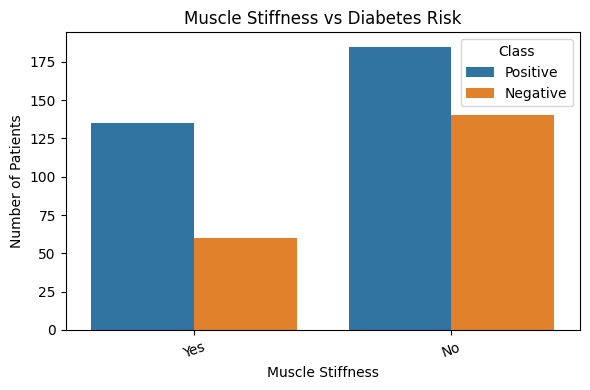

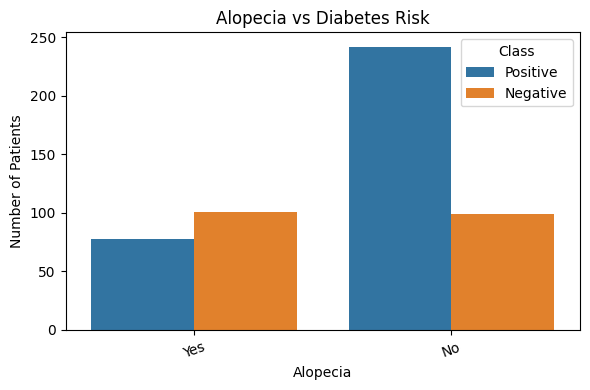

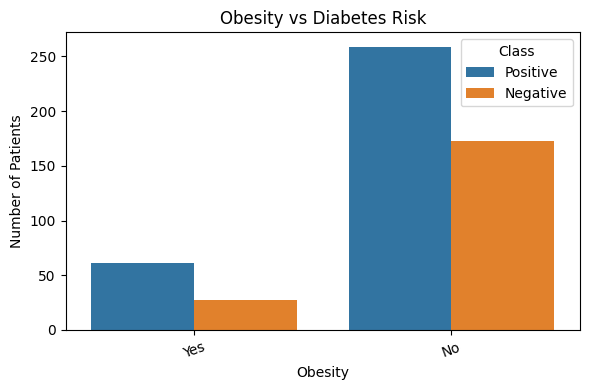

In [32]:
for col in categorical_columns:
    if col != "class":
        plt.figure(figsize=(6, 4))
        sns.countplot(data=df, x=col, hue="class")
        plt.title(f"{col.replace('_', ' ').title()} vs Diabetes Risk")
        plt.xlabel(col.replace("_", " ").title())
        plt.ylabel("Number of Patients")
        plt.xticks(rotation=20)
        plt.legend(title="Class")
        plt.tight_layout()
        plt.show()

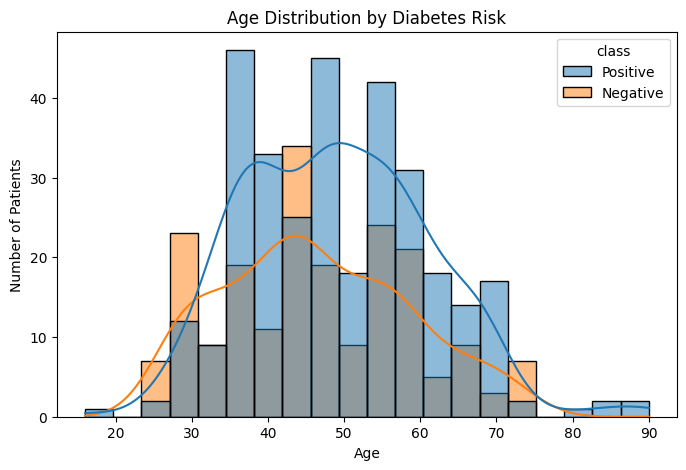

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    hue="class",
    bins=20,
    kde=True
)

plt.title("Age Distribution by Diabetes Risk")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

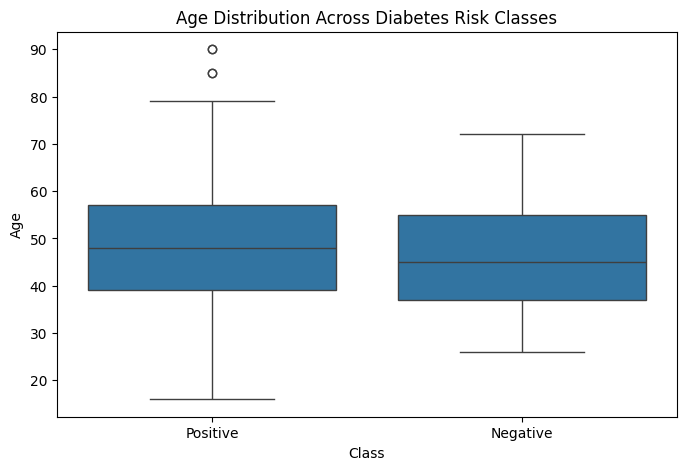

In [34]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="class",
    y="age"
)

plt.title("Age Distribution Across Diabetes Risk Classes")
plt.xlabel("Class")
plt.ylabel("Age")
plt.show()

In [36]:
df_analysis = df.copy()

for col in df_analysis.columns:
    if df_analysis[col].dtype == "object":
        df_analysis[col] = df_analysis[col].str.strip().str.lower()

mapping = {
    "yes": 1,
    "no": 0,
    "positive": 1,
    "negative": 0,
    "male": 1,
    "female": 0
}

for col in df_analysis.columns:
    df_analysis[col] = df_analysis[col].map(mapping).fillna(df_analysis[col])

In [37]:
df_analysis.head()

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
0,40.0,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58.0,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41.0,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45.0,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60.0,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


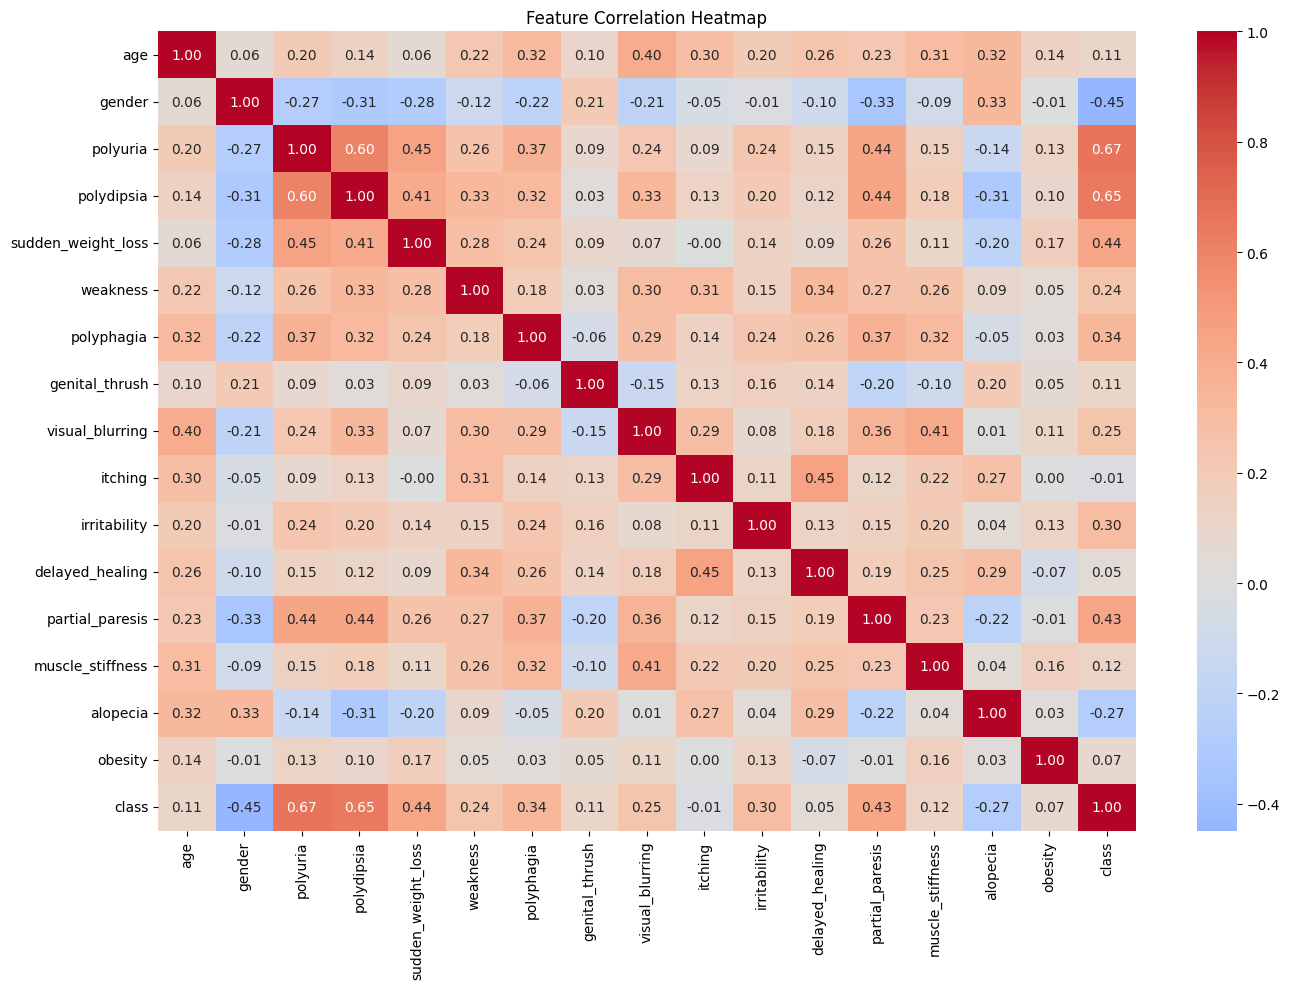

In [38]:
plt.figure(figsize=(14, 10))

correlation = df_analysis.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [39]:
target_corr = correlation["class"].sort_values(ascending=False)

print(target_corr)

class                 1.000000
polyuria              0.665922
polydipsia            0.648734
sudden_weight_loss    0.436568
partial_paresis       0.432288
polyphagia            0.342504
irritability          0.299467
visual_blurring       0.251300
weakness              0.243275
muscle_stiffness      0.122474
genital_thrush        0.110288
age                   0.108679
obesity               0.072173
delayed_healing       0.046980
itching              -0.013384
alopecia             -0.267512
gender               -0.449233
Name: class, dtype: float64


In [40]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 269


In [41]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())


age
[40 58 41 45 60 55 57 66 67 70 44 38 35 61 54 43 62 39 48 32 42 52 53 37
 49 63 30 50 46 36 51 59 65 25 47 28 68 56 31 85 90 72 69 79 34 16 33 64
 27 29 26]

gender
['Male' 'Female']

polyuria
['No' 'Yes']

polydipsia
['Yes' 'No']

sudden_weight_loss
['No' 'Yes']

weakness
['Yes' 'No']

polyphagia
['No' 'Yes']

genital_thrush
['No' 'Yes']

visual_blurring
['No' 'Yes']

itching
['Yes' 'No']

irritability
['No' 'Yes']

delayed_healing
['Yes' 'No']

partial_paresis
['No' 'Yes']

muscle_stiffness
['Yes' 'No']

alopecia
['Yes' 'No']

obesity
['Yes' 'No']

class
['Positive' 'Negative']


In [42]:
from pathlib import Path

Path("data/raw").mkdir(parents=True, exist_ok=True)

df.to_csv(
    "data/raw/diabetes_data_original.csv",
    index=False
)

print("✅ Original dataset saved.")

✅ Original dataset saved.


In [43]:
X = df.drop(columns=["class"])
y = df["class"].str.strip().str.lower().map({
    "negative": 0,
    "positive": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (520, 16)
y shape: (520,)

Target distribution:
class
1    320
0    200
Name: count, dtype: int64


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training samples: 416
Testing samples: 104

Training distribution:
class
1    256
0    160
Name: count, dtype: int64

Testing distribution:
class
1    64
0    40
Name: count, dtype: int64


In [45]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()

categorical_features = [
    col for col in X_train.columns
    if col not in numeric_features
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age']

Categorical features:
['gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity']


In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [47]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (416, 16)
Processed training shape: (416, 31)
Original testing shape: (104, 16)
Processed testing shape: (104, 31)


In [48]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nFirst 30 features:")

for feature in feature_names[:30]:
    print(feature)

Number of processed features: 31

First 30 features:
numeric__age
categorical__gender_Female
categorical__gender_Male
categorical__polyuria_No
categorical__polyuria_Yes
categorical__polydipsia_No
categorical__polydipsia_Yes
categorical__sudden_weight_loss_No
categorical__sudden_weight_loss_Yes
categorical__weakness_No
categorical__weakness_Yes
categorical__polyphagia_No
categorical__polyphagia_Yes
categorical__genital_thrush_No
categorical__genital_thrush_Yes
categorical__visual_blurring_No
categorical__visual_blurring_Yes
categorical__itching_No
categorical__itching_Yes
categorical__irritability_No
categorical__irritability_Yes
categorical__delayed_healing_No
categorical__delayed_healing_Yes
categorical__partial_paresis_No
categorical__partial_paresis_Yes
categorical__muscle_stiffness_No
categorical__muscle_stiffness_Yes
categorical__alopecia_No
categorical__alopecia_Yes
categorical__obesity_No


In [49]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("✅ Logistic Regression trained successfully.")

✅ Logistic Regression trained successfully.


In [50]:
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions:")
print(y_pred_lr[:20])

print("\nProbabilities:")
print(y_prob_lr[:20])

Predictions:
[0 1 1 0 0 1 1 0 1 0 1 1 1 1 1 1 0 0 1 1]

Probabilities:
[0.19738119 0.9310003  0.9914713  0.24797764 0.04469678 0.89976384
 0.99967414 0.04011988 0.99903784 0.03895104 0.99965585 0.91584433
 0.99962136 0.99824253 0.99993842 0.96895563 0.28984343 0.16086166
 0.9997808  0.99171394]


In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))
print("PR-AUC   :", average_precision_score(y_test, y_prob_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.9326923076923077
Precision: 0.9830508474576272
Recall   : 0.90625
F1 Score : 0.943089430894309
ROC-AUC  : 0.990234375
PR-AUC   : 0.9942083183283665

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92        40
           1       0.98      0.91      0.94        64

    accuracy                           0.93       104
   macro avg       0.92      0.94      0.93       104
weighted avg       0.94      0.93      0.93       104



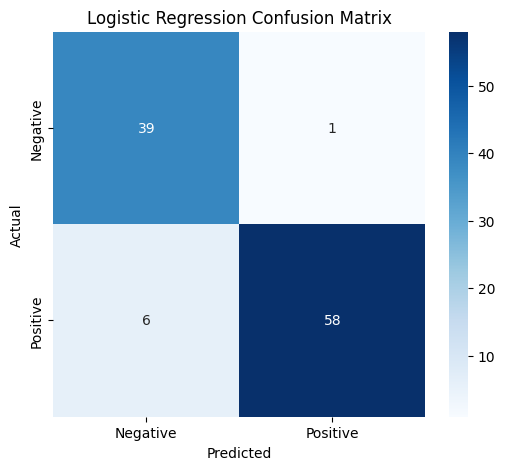

In [52]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [53]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lr).ravel()

specificity = tn / (tn + fp)

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

print("\nSpecificity:", specificity)

True Negative : 39
False Positive: 1
False Negative: 6
True Positive : 58

Specificity: 0.975


In [54]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_prob_lr)

print("Brier Score:", brier)

Brier Score: 0.049435351713592764


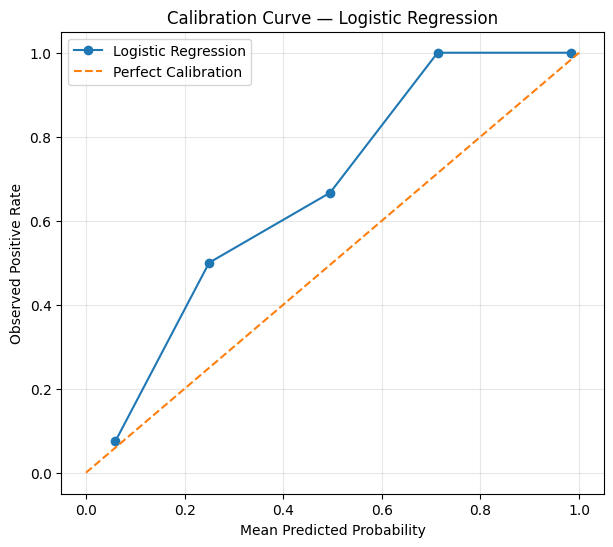

In [55]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob_lr,
    n_bins=5
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("Calibration Curve — Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [56]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [57]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))
print("PR-AUC   :", average_precision_score(y_test, y_prob_dt))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt).ravel()
print("Specificity:", tn / (tn + fp))
print("Brier Score:", brier_score_loss(y_test, y_prob_dt))

Accuracy : 0.9519230769230769
Precision: 1.0
Recall   : 0.921875
F1 Score : 0.959349593495935
ROC-AUC  : 0.9609375
PR-AUC   : 0.9699519230769231
Specificity: 1.0
Brier Score: 0.04807692307692308


In [58]:
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [59]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC   :", average_precision_score(y_test, y_prob_rf))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
print("Specificity:", tn / (tn + fp))
print("Brier Score:", brier_score_loss(y_test, y_prob_rf))

Accuracy : 0.9903846153846154
Precision: 0.9846153846153847
Recall   : 1.0
F1 Score : 0.9922480620155039
ROC-AUC  : 0.9980468750000001
PR-AUC   : 0.9987592952165837
Specificity: 0.975
Brier Score: 0.01427926682692308


In [60]:
from sklearn.svm import SVC

svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

print("SVM trained successfully!")

SVM trained successfully!


In [61]:
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_svm))
print("PR-AUC   :", average_precision_score(y_test, y_prob_svm))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_svm).ravel()
print("Specificity:", tn / (tn + fp))
print("Brier Score:", brier_score_loss(y_test, y_prob_svm))

Accuracy : 0.9711538461538461
Precision: 0.9841269841269841
Recall   : 0.96875
F1 Score : 0.9763779527559056
ROC-AUC  : 0.9984375
PR-AUC   : 0.9990154427575673
Specificity: 0.975
Brier Score: 0.011345215831852776


In [62]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [63]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))
print("PR-AUC   :", average_precision_score(y_test, y_prob_xgb))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_xgb).ravel()
print("Specificity:", tn / (tn + fp))
print("Brier Score:", brier_score_loss(y_test, y_prob_xgb))

Accuracy : 0.9807692307692307
Precision: 1.0
Recall   : 0.96875
F1 Score : 0.9841269841269841
ROC-AUC  : 0.999609375
PR-AUC   : 0.9997596153846153
Specificity: 1.0
Brier Score: 0.012264770182922605


In [64]:
from catboost import CatBoostClassifier

catboost_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostClassifier(
        iterations=300,
        depth=5,
        learning_rate=0.05,
        verbose=False,
        random_seed=42
    ))
])

catboost_model.fit(X_train, y_train)

y_pred_cb = catboost_model.predict(X_test).astype(int).ravel()
y_prob_cb = catboost_model.predict_proba(X_test)[:, 1]

print("CatBoost trained successfully!")

CatBoost trained successfully!


In [65]:
print("Accuracy :", accuracy_score(y_test, y_pred_cb))
print("Precision:", precision_score(y_test, y_pred_cb))
print("Recall   :", recall_score(y_test, y_pred_cb))
print("F1 Score :", f1_score(y_test, y_pred_cb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_cb))
print("PR-AUC   :", average_precision_score(y_test, y_prob_cb))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cb).ravel()
print("Specificity:", tn / (tn + fp))
print("Brier Score:", brier_score_loss(y_test, y_prob_cb))

Accuracy : 0.9807692307692307
Precision: 1.0
Recall   : 0.96875
F1 Score : 0.9841269841269841
ROC-AUC  : 1.0
PR-AUC   : 1.0
Specificity: 1.0
Brier Score: 0.010460013685359397


In [71]:
import pandas as pd

models_results = {
    "Logistic Regression": (y_pred_lr, y_prob_lr),
    "Decision Tree": (y_pred_dt, y_prob_dt),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "SVM": (y_pred_svm, y_prob_svm),
    "XGBoost": (y_pred_xgb, y_prob_xgb),
    "CatBoost": (y_pred_cb, y_prob_cb)
}

results = []

for name, (pred, prob) in models_results.items():

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "Specificity": tn / (tn + fp),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob),
        "Brier Score": brier_score_loss(y_test, prob)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,PR-AUC,Brier Score
0,Random Forest,0.990385,0.984615,1.000000,0.975,0.992248,0.998047,0.998759,0.014279
1,XGBoost,0.980769,1.000000,0.968750,1.000,0.984127,0.999609,0.999760,0.012265
2,CatBoost,0.980769,1.000000,0.968750,1.000,0.984127,1.000000,1.000000,0.010460
3,SVM,0.971154,0.984127,0.968750,0.975,0.976378,0.998437,0.999015,0.011345
4,Decision Tree,0.951923,1.000000,0.921875,1.000,0.959350,0.960938,0.969952,0.048077
5,Logistic Regression,0.932692,0.983051,0.906250,0.975,0.943089,0.990234,0.994208,0.049435


In [72]:
results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "Specificity": "{:.4f}",
    "F1": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}",
    "Brier Score": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,PR-AUC,Brier Score
0,Random Forest,0.9904,0.9846,1.0000,0.9750,0.9922,0.9980,0.9988,0.0143
1,XGBoost,0.9808,1.0000,0.9688,1.0000,0.9841,0.9996,0.9998,0.0123
2,CatBoost,0.9808,1.0000,0.9688,1.0000,0.9841,1.0000,1.0000,0.0105
3,SVM,0.9712,0.9841,0.9688,0.9750,0.9764,0.9984,0.9990,0.0113
4,Decision Tree,0.9519,1.0000,0.9219,1.0000,0.9593,0.9609,0.9700,0.0481
5,Logistic Regression,0.9327,0.9831,0.9062,0.9750,0.9431,0.9902,0.9942,0.0494


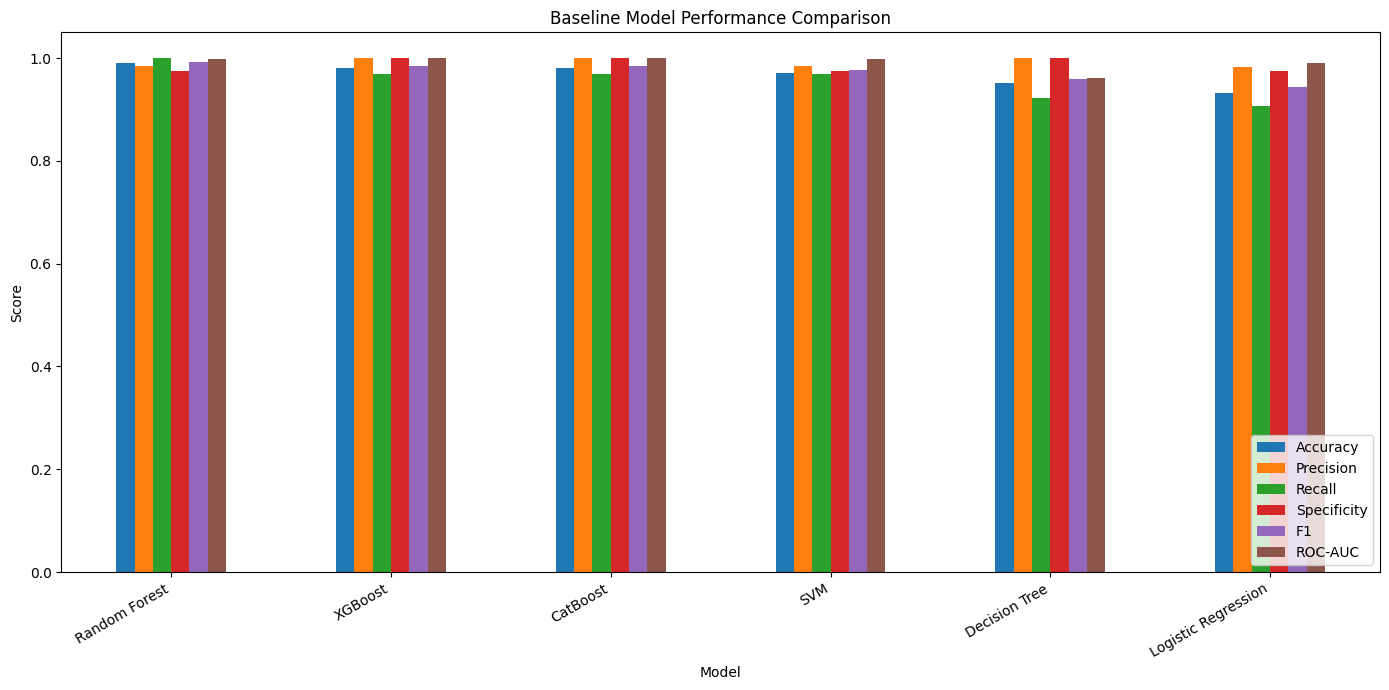

In [73]:
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "ROC-AUC"
]

plot_df = results_df.set_index("Model")[metrics_to_plot]

plot_df.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Baseline Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

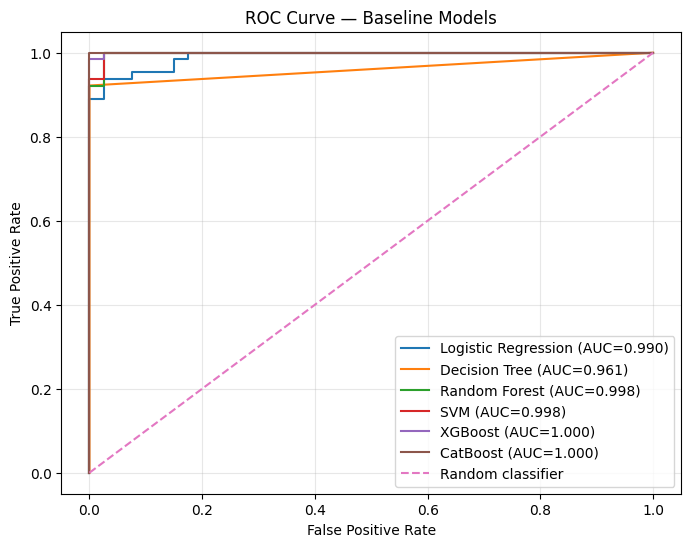

In [74]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, (pred, prob) in models_results.items():

    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

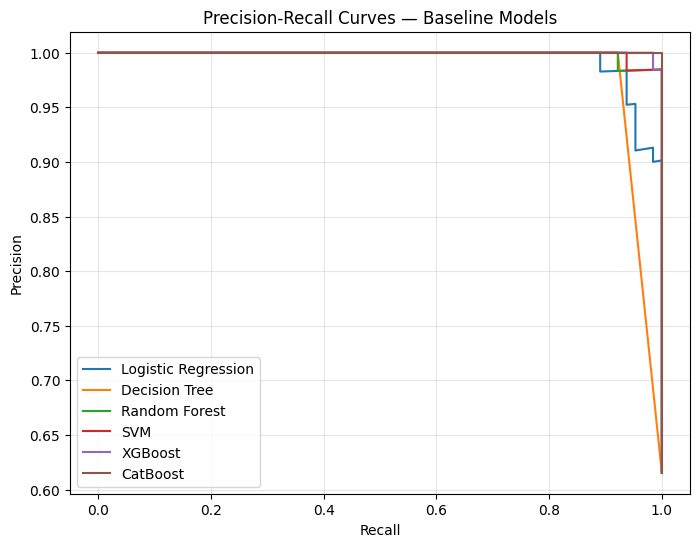

In [75]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))

for name, (pred, prob) in models_results.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        prob
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Baseline Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [76]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss
)

In [77]:
def calculate_metrics(y_true, y_pred, y_prob):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    specificity = tn / (tn + fp)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "Specificity": specificity,
        "F1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true, y_prob
        ),
        "PR-AUC": average_precision_score(
            y_true, y_prob
        ),
        "Brier Score": brier_score_loss(
            y_true, y_prob
        )
    }

In [78]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Stratified Cross-Validation created.")

5-Fold Stratified Cross-Validation created.


In [79]:
cv_results = []

models_for_cv = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=5,
        learning_rate=0.05,
        verbose=False,
        random_seed=42
    )
}

for name, model in models_for_cv.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Out-of-fold probabilities
    probabilities = cross_val_predict(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=1
    )[:, 1]

    predictions = (probabilities >= 0.5).astype(int)

    metrics = calculate_metrics(
        y_train,
        predictions,
        probabilities
    )

    metrics["Model"] = name

    cv_results.append(metrics)

    print(f"✅ Completed: {name}")

✅ Completed: Logistic Regression
✅ Completed: Decision Tree
✅ Completed: Random Forest
✅ Completed: SVM
✅ Completed: XGBoost
✅ Completed: CatBoost


In [80]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1",
        "ROC-AUC",
        "PR-AUC",
        "Brier Score"
    ]
]

cv_results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,PR-AUC,Brier Score
0,XGBoost,0.975962,0.980469,0.980469,0.96875,0.980469,0.991528,0.994992,0.026261
1,Random Forest,0.968750,0.972763,0.976562,0.95625,0.974659,0.996277,0.997568,0.023479
2,CatBoost,0.968750,0.972763,0.976562,0.95625,0.974659,0.997217,0.998304,0.022613
3,SVM,0.959135,0.961390,0.972656,0.93750,0.966990,0.994995,0.996787,0.026543
4,Decision Tree,0.959135,0.964981,0.968750,0.94375,0.966862,0.956250,0.954056,0.040865
5,Logistic Regression,0.927885,0.955645,0.925781,0.93125,0.940476,0.970190,0.983641,0.062690


In [81]:
cv_results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "Specificity": "{:.4f}",
    "F1": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}",
    "Brier Score": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,PR-AUC,Brier Score
0,Logistic Regression,0.9279,0.9556,0.9258,0.9313,0.9405,0.9702,0.9836,0.0627
1,Decision Tree,0.9591,0.9650,0.9688,0.9437,0.9669,0.9562,0.9541,0.0409
2,Random Forest,0.9688,0.9728,0.9766,0.9563,0.9747,0.9963,0.9976,0.0235
3,SVM,0.9591,0.9614,0.9727,0.9375,0.9670,0.9950,0.9968,0.0265
4,XGBoost,0.9760,0.9805,0.9805,0.9688,0.9805,0.9915,0.9950,0.0263
5,CatBoost,0.9688,0.9728,0.9766,0.9563,0.9747,0.9972,0.9983,0.0226


In [82]:
from pathlib import Path

Path("results/tables").mkdir(
    parents=True,
    exist_ok=True
)

cv_results_df.to_csv(
    "results/tables/5_fold_cv_results.csv",
    index=False
)

print("✅ 5-fold CV results saved.")

✅ 5-fold CV results saved.


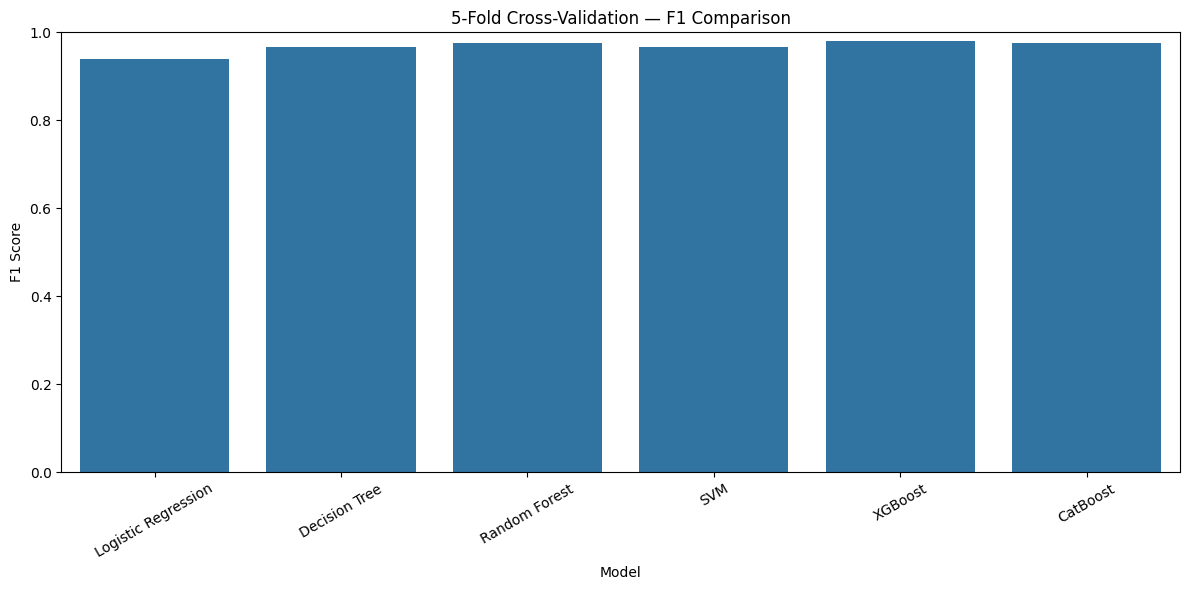

In [83]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=cv_results_df,
    x="Model",
    y="F1"
)

plt.title("5-Fold Cross-Validation — F1 Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [84]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif

numeric_features_fs = X_train.select_dtypes(include=["number"]).columns.tolist()

categorical_features_fs = [
    col for col in X_train.columns
    if col not in numeric_features_fs
]

numeric_pipeline_fs = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_fs = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

preprocessor_fs = ColumnTransformer([
    ("numeric", numeric_pipeline_fs, numeric_features_fs),
    ("categorical", categorical_pipeline_fs, categorical_features_fs)
])

print("✅ Feature-selection preprocessing pipeline created.")

✅ Feature-selection preprocessing pipeline created.


In [85]:
X_train_fs = preprocessor_fs.fit_transform(X_train)

print("Original features:", X_train.shape[1])
print("Processed features:", X_train_fs.shape[1])

Original features: 16
Processed features: 16


In [86]:
feature_counts = [5, 8, 12, 16]

print("Feature counts to test:", feature_counts)

Feature counts to test: [5, 8, 12, 16]


In [87]:
feature_selection_results = []

models_for_feature_selection = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

for k in feature_counts:

    print(f"\n========== TOP {k} FEATURES ==========")

    for name, model in models_for_feature_selection.items():

        pipeline_fs = Pipeline([
            ("preprocessor", preprocessor_fs),

            ("feature_selection",
             SelectKBest(
                 score_func=mutual_info_classif,
                 k=k
             )),

            ("model", model)
        ])

        probabilities = cross_val_predict(
            pipeline_fs,
            X_train,
            y_train,
            cv=cv,
            method="predict_proba",
            n_jobs=1
        )[:, 1]

        predictions = (
            probabilities >= 0.5
        ).astype(int)

        metrics = calculate_metrics(
            y_train,
            predictions,
            probabilities
        )

        metrics["Model"] = name
        metrics["Features"] = k

        feature_selection_results.append(metrics)

        print(
            f"{name}: "
            f"F1={metrics['F1']:.4f}, "
            f"Recall={metrics['Recall']:.4f}, "
            f"ROC-AUC={metrics['ROC-AUC']:.4f}"
        )


========== TOP 5 FEATURES ==========
Logistic Regression: F1=0.8994, Recall=0.8906, ROC-AUC=0.9455
Random Forest: F1=0.9194, Recall=0.9141, ROC-AUC=0.9630
SVM: F1=0.9055, Recall=0.8984, ROC-AUC=0.9397
XGBoost: F1=0.9210, Recall=0.9336, ROC-AUC=0.9667

========== TOP 8 FEATURES ==========
Logistic Regression: F1=0.9116, Recall=0.8867, ROC-AUC=0.9544
Random Forest: F1=0.9650, Recall=0.9688, ROC-AUC=0.9842
SVM: F1=0.9333, Recall=0.9297, ROC-AUC=0.9797
XGBoost: F1=0.9529, Recall=0.9492, ROC-AUC=0.9824

========== TOP 12 FEATURES ==========
Logistic Regression: F1=0.9280, Recall=0.9062, ROC-AUC=0.9657
Random Forest: F1=0.9747, Recall=0.9766, ROC-AUC=0.9962
SVM: F1=0.9529, Recall=0.9492, ROC-AUC=0.9910
XGBoost: F1=0.9667, Recall=0.9648, ROC-AUC=0.9896

========== TOP 16 FEATURES ==========
Logistic Regression: F1=0.9320, Recall=0.9102, ROC-AUC=0.9691
Random Forest: F1=0.9747, Recall=0.9766, ROC-AUC=0.9972
SVM: F1=0.9647, Recall=0.9609, ROC-AUC=0.9950
XGBoost: F1=0.9765, Recall=0.9727, ROC-A

In [88]:
feature_results_df = pd.DataFrame(
    feature_selection_results
)

feature_results_df = feature_results_df[
    [
        "Model",
        "Features",
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1",
        "ROC-AUC",
        "PR-AUC",
        "Brier Score"
    ]
]

feature_results_df.sort_values(
    ["Model", "Features"]
).reset_index(drop=True)

,Model,Features,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,PR-AUC,Brier Score
0,Logistic Regression,5,0.877404,0.908367,0.890625,0.85625,0.899408,0.945532,0.969705,0.087037
1,Logistic Regression,8,0.894231,0.938017,0.886719,0.90625,0.911647,0.954407,0.974608,0.082308
2,Logistic Regression,12,0.913462,0.950820,0.906250,0.92500,0.928000,0.965698,0.980390,0.069135
3,Logistic Regression,16,0.918269,0.954918,0.910156,0.93125,0.932000,0.969141,0.983061,0.065519
4,Random Forest,5,0.901442,0.924901,0.914062,0.88125,0.919450,0.962964,0.978383,0.070685
5,Random Forest,8,0.956731,0.961240,0.968750,0.93750,0.964981,0.984167,0.989362,0.038782
6,Random Forest,12,0.968750,0.972763,0.976562,0.95625,0.974659,0.996191,0.997637,0.025815
7,Random Forest,16,0.968750,0.972763,0.976562,0.95625,0.974659,0.997205,0.998210,0.022559
8,SVM,5,0.884615,0.912698,0.898438,0.86250,0.905512,0.939697,0.964305,0.086655
9,SVM,8,0.918269,0.937008,0.929688,0.90000,0.933333,0.979712,0.988618,0.056201


In [89]:
feature_results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "Specificity": "{:.4f}",
    "F1": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}",
    "Brier Score": "{:.4f}"
})

,Model,Features,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,PR-AUC,Brier Score
0,Logistic Regression,5,0.8774,0.9084,0.8906,0.8562,0.8994,0.9455,0.9697,0.0870
1,Random Forest,5,0.9014,0.9249,0.9141,0.8812,0.9194,0.9630,0.9784,0.0707
2,SVM,5,0.8846,0.9127,0.8984,0.8625,0.9055,0.9397,0.9643,0.0867
3,XGBoost,5,0.9014,0.9087,0.9336,0.8500,0.9210,0.9667,0.9806,0.0694
4,Logistic Regression,8,0.8942,0.9380,0.8867,0.9062,0.9116,0.9544,0.9746,0.0823
5,Random Forest,8,0.9567,0.9612,0.9688,0.9375,0.9650,0.9842,0.9894,0.0388
6,SVM,8,0.9183,0.9370,0.9297,0.9000,0.9333,0.9797,0.9886,0.0562
7,XGBoost,8,0.9423,0.9567,0.9492,0.9313,0.9529,0.9824,0.9895,0.0451
8,Logistic Regression,12,0.9135,0.9508,0.9062,0.9250,0.9280,0.9657,0.9804,0.0691
9,Random Forest,12,0.9688,0.9728,0.9766,0.9563,0.9747,0.9962,0.9976,0.0258


In [90]:
feature_results_df.to_csv(
    "results/tables/feature_efficiency_results.csv",
    index=False
)

print("✅ Feature-efficiency results saved.")

✅ Feature-efficiency results saved.


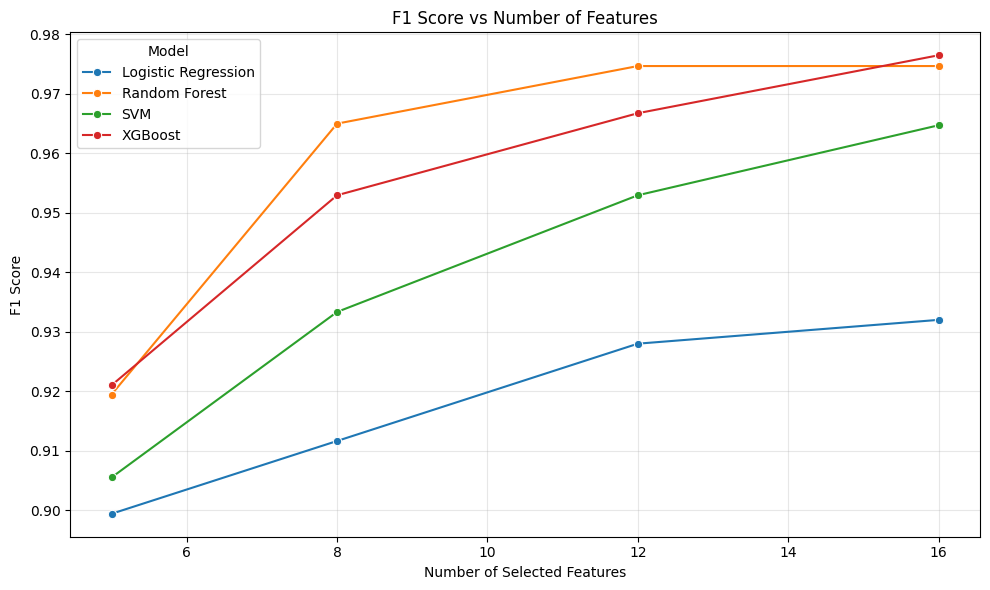

In [91]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=feature_results_df,
    x="Features",
    y="F1",
    hue="Model",
    marker="o"
)

plt.title("F1 Score vs Number of Features")
plt.xlabel("Number of Selected Features")
plt.ylabel("F1 Score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

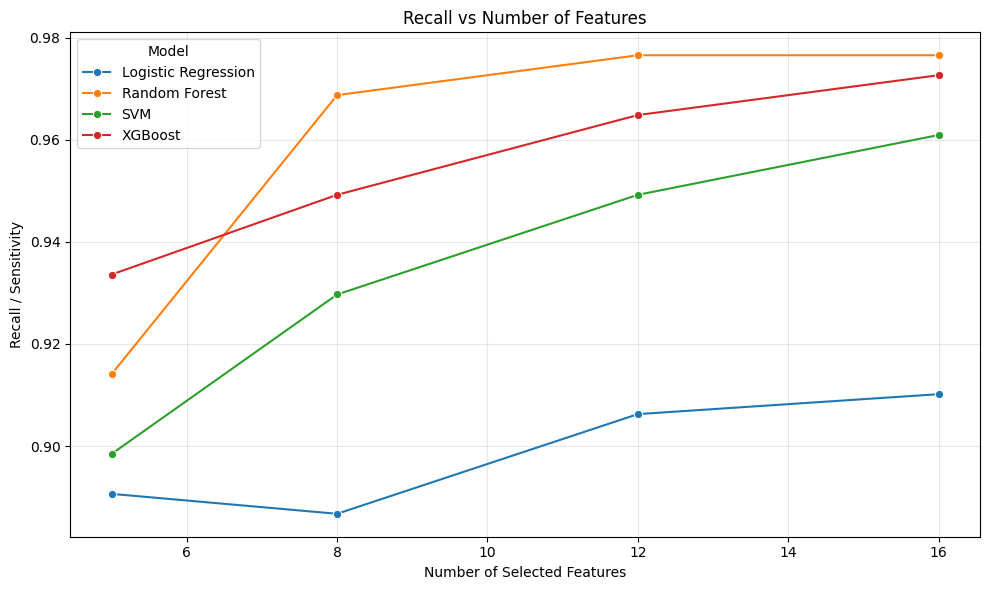

In [92]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=feature_results_df,
    x="Features",
    y="Recall",
    hue="Model",
    marker="o"
)

plt.title("Recall vs Number of Features")
plt.xlabel("Number of Selected Features")
plt.ylabel("Recall / Sensitivity")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [93]:
feature_results_df.sort_values(
    by="F1",
    ascending=False
).head(10)

,Model,Features,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,PR-AUC,Brier Score
15,XGBoost,16,0.971154,0.980315,0.972656,0.96875,0.976471,0.991748,0.995018,0.027506
9,Random Forest,12,0.968750,0.972763,0.976562,0.95625,0.974659,0.996191,0.997637,0.025815
13,Random Forest,16,0.968750,0.972763,0.976562,0.95625,0.974659,0.997205,0.998210,0.022559
11,XGBoost,12,0.959135,0.968627,0.964844,0.95000,0.966732,0.989624,0.993766,0.031430
5,Random Forest,8,0.956731,0.961240,0.968750,0.93750,0.964981,0.984167,0.989362,0.038782
14,SVM,16,0.956731,0.968504,0.960938,0.95000,0.964706,0.994971,0.996781,0.029129
10,SVM,12,0.942308,0.956693,0.949219,0.93125,0.952941,0.990991,0.994473,0.041110
7,XGBoost,8,0.942308,0.956693,0.949219,0.93125,0.952941,0.982361,0.989514,0.045130
6,SVM,8,0.918269,0.937008,0.929688,0.90000,0.933333,0.979712,0.988618,0.056201
12,Logistic Regression,16,0.918269,0.954918,0.910156,0.93125,0.932000,0.969141,0.983061,0.065519


In [94]:
selector_pipeline = Pipeline([
    ("preprocessor", preprocessor_fs),
    ("feature_selection",
     SelectKBest(
         score_func=mutual_info_classif,
         k=8
     ))
])

selector_pipeline.fit(X_train, y_train)

selector = selector_pipeline.named_steps["feature_selection"]

selected_mask = selector.get_support()

feature_names_fs = (
    numeric_features_fs +
    categorical_features_fs
)

selected_features = [
    feature_names_fs[i]
    for i, selected in enumerate(selected_mask)
    if selected
]

print("Selected features:")
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

Selected features:
1. age
2. gender
3. polyuria
4. polydipsia
5. sudden_weight_loss
6. polyphagia
7. partial_paresis
8. alopecia


In [95]:
feature_results_df.sort_values(
    ["Model", "Features"]
).reset_index(drop=True)

,Model,Features,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,PR-AUC,Brier Score
0,Logistic Regression,5,0.877404,0.908367,0.890625,0.85625,0.899408,0.945532,0.969705,0.087037
1,Logistic Regression,8,0.894231,0.938017,0.886719,0.90625,0.911647,0.954407,0.974608,0.082308
2,Logistic Regression,12,0.913462,0.950820,0.906250,0.92500,0.928000,0.965698,0.980390,0.069135
3,Logistic Regression,16,0.918269,0.954918,0.910156,0.93125,0.932000,0.969141,0.983061,0.065519
4,Random Forest,5,0.901442,0.924901,0.914062,0.88125,0.919450,0.962964,0.978383,0.070685
5,Random Forest,8,0.956731,0.961240,0.968750,0.93750,0.964981,0.984167,0.989362,0.038782
6,Random Forest,12,0.968750,0.972763,0.976562,0.95625,0.974659,0.996191,0.997637,0.025815
7,Random Forest,16,0.968750,0.972763,0.976562,0.95625,0.974659,0.997205,0.998210,0.022559
8,SVM,5,0.884615,0.912698,0.898438,0.86250,0.905512,0.939697,0.964305,0.086655
9,SVM,8,0.918269,0.937008,0.929688,0.90000,0.933333,0.979712,0.988618,0.056201


In [96]:
feature_results_df[
    ["Model", "Features", "Recall", "Specificity", "F1", "ROC-AUC", "Brier Score"]
].sort_values(
    "F1",
    ascending=False
)

,Model,Features,Recall,Specificity,F1,ROC-AUC,Brier Score
15,XGBoost,16,0.972656,0.96875,0.976471,0.991748,0.027506
9,Random Forest,12,0.976562,0.95625,0.974659,0.996191,0.025815
13,Random Forest,16,0.976562,0.95625,0.974659,0.997205,0.022559
11,XGBoost,12,0.964844,0.95000,0.966732,0.989624,0.031430
5,Random Forest,8,0.968750,0.93750,0.964981,0.984167,0.038782
14,SVM,16,0.960938,0.95000,0.964706,0.994971,0.029129
10,SVM,12,0.949219,0.93125,0.952941,0.990991,0.041110
7,XGBoost,8,0.949219,0.93125,0.952941,0.982361,0.045130
6,SVM,8,0.929688,0.90000,0.933333,0.979712,0.056201
12,Logistic Regression,16,0.910156,0.93125,0.932000,0.969141,0.065519


In [97]:
print("Number of rows:", len(feature_results_df))
print("\nModels tested:")
print(feature_results_df["Model"].unique())

print("\nFeature counts tested:")
print(sorted(feature_results_df["Features"].unique()))

Number of rows: 16

Models tested:
['Logistic Regression' 'Random Forest' 'SVM' 'XGBoost']

Feature counts tested:
[np.int64(5), np.int64(8), np.int64(12), np.int64(16)]


In [98]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from collections import Counter
import pandas as pd
import numpy as np

In [99]:
feature_names_raw = X_train.columns.tolist()

stability_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

selected_features_by_fold = []

for fold, (train_idx, val_idx) in enumerate(
    stability_cv.split(X_train, y_train),
    start=1
):

    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]

    numeric_cols = X_fold_train.select_dtypes(
        include=["number"]
    ).columns.tolist()

    categorical_cols = [
        col for col in X_fold_train.columns
        if col not in numeric_cols
    ]

    fold_preprocessor = ColumnTransformer([
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_cols
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                ))
            ]),
            categorical_cols
        )
    ])

    X_fold_processed = fold_preprocessor.fit_transform(
        X_fold_train
    )

    fold_feature_names = (
        numeric_cols + categorical_cols
    )

    selector = SelectKBest(
        score_func=mutual_info_classif,
        k=8
    )

    selector.fit(
        X_fold_processed,
        y_fold_train
    )

    mask = selector.get_support()

    selected = [
        fold_feature_names[i]
        for i, selected_flag in enumerate(mask)
        if selected_flag
    ]

    selected_features_by_fold.append(selected)

    print(f"\nFold {fold}")
    print("-" * 30)

    for feature in selected:
        print(feature)


Fold 1
------------------------------
age
gender
polyuria
polydipsia
sudden_weight_loss
polyphagia
genital_thrush
partial_paresis

Fold 2
------------------------------
age
gender
polyuria
polydipsia
sudden_weight_loss
polyphagia
partial_paresis
muscle_stiffness

Fold 3
------------------------------
age
gender
polyuria
polydipsia
sudden_weight_loss
visual_blurring
irritability
partial_paresis

Fold 4
------------------------------
age
gender
polyuria
polydipsia
sudden_weight_loss
polyphagia
partial_paresis
alopecia

Fold 5
------------------------------
age
gender
polyuria
polydipsia
sudden_weight_loss
genital_thrush
irritability
partial_paresis


In [100]:
feature_counter = Counter()

for selected in selected_features_by_fold:
    feature_counter.update(selected)

stability_df = pd.DataFrame(
    feature_counter.items(),
    columns=["Feature", "Selection_Count"]
)

stability_df["Selection_Percentage"] = (
    stability_df["Selection_Count"] / 5 * 100
)

stability_df = stability_df.sort_values(
    "Selection_Count",
    ascending=False
).reset_index(drop=True)

stability_df

,Feature,Selection_Count,Selection_Percentage
0,age,5,100.0
1,gender,5,100.0
2,polyuria,5,100.0
3,polydipsia,5,100.0
4,sudden_weight_loss,5,100.0
5,partial_paresis,5,100.0
6,polyphagia,3,60.0
7,genital_thrush,2,40.0
8,irritability,2,40.0
9,muscle_stiffness,1,20.0


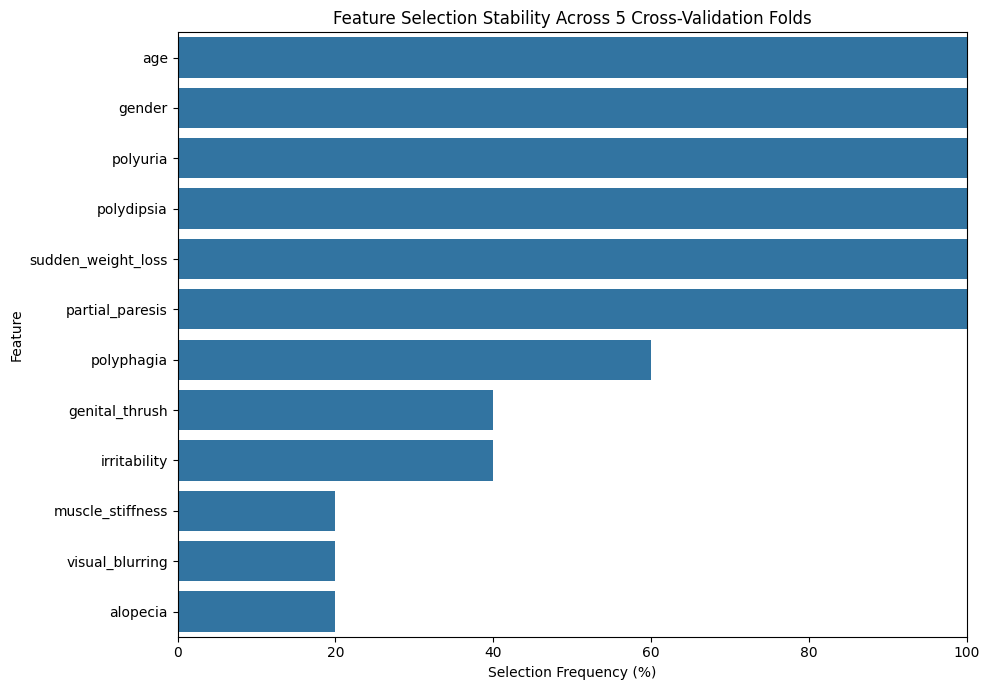

In [101]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=stability_df,
    x="Selection_Percentage",
    y="Feature"
)

plt.xlabel("Selection Frequency (%)")
plt.ylabel("Feature")
plt.title(
    "Feature Selection Stability Across 5 Cross-Validation Folds"
)

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [102]:
stability_df.to_csv(
    "results/tables/feature_selection_stability.csv",
    index=False
)

print("✅ Feature stability results saved.")

✅ Feature stability results saved.


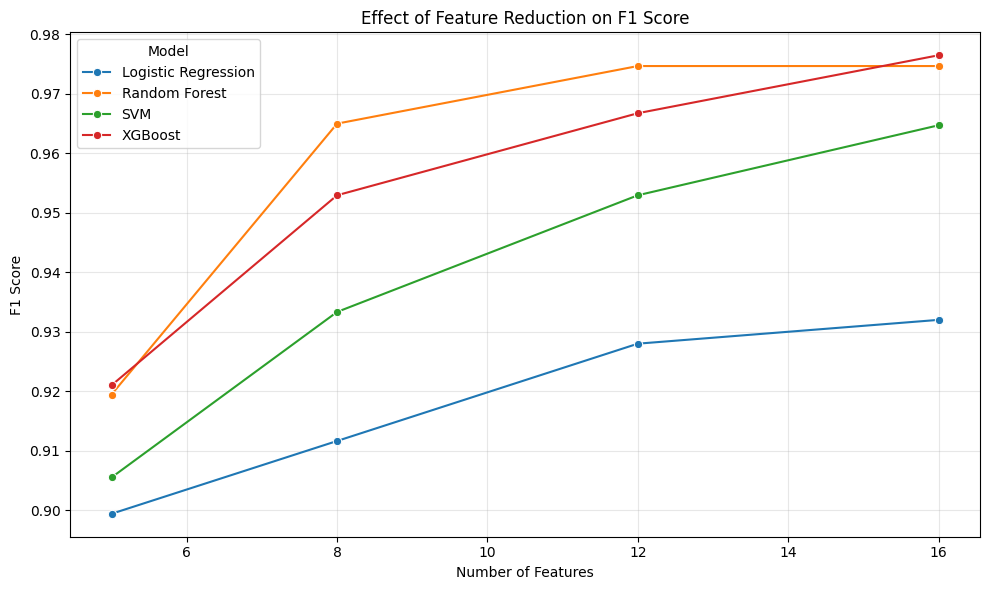

In [103]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=feature_results_df,
    x="Features",
    y="F1",
    hue="Model",
    marker="o"
)

plt.title(
    "Effect of Feature Reduction on F1 Score"
)

plt.xlabel("Number of Features")
plt.ylabel("F1 Score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

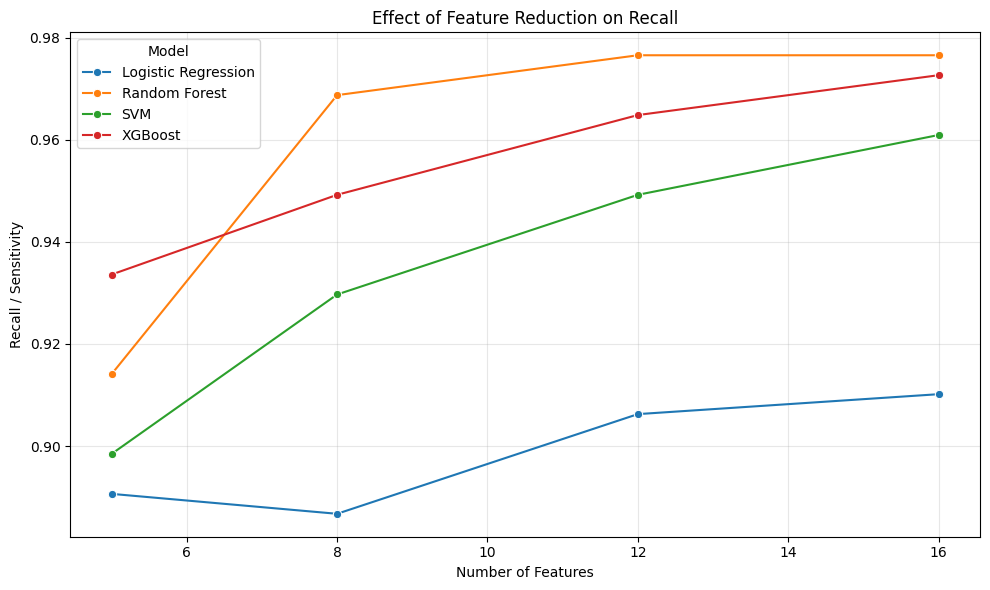

In [104]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=feature_results_df,
    x="Features",
    y="Recall",
    hue="Model",
    marker="o"
)

plt.title(
    "Effect of Feature Reduction on Recall"
)

plt.xlabel("Number of Features")
plt.ylabel("Recall / Sensitivity")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [105]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform, randint

In [106]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        random_state=42
    ))
])

lr_params = {
    "model__C": loguniform(0.001, 100),
    "model__class_weight": [None, "balanced"],
    "model__solver": ["lbfgs", "liblinear"]
}

lr_search = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=lr_params,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

lr_search.fit(X_train, y_train)

print("Best parameters:")
print(lr_search.best_params_)

print("\nBest CV F1:")
print(lr_search.best_score_)

Best parameters:
{'model__C': np.float64(14.528246637516036), 'model__class_weight': 'balanced', 'model__solver': 'liblinear'}

Best CV F1:
0.9485643386252438


In [108]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

rf_params = {
    "model__n_estimators": randint(200, 800),
    "model__max_depth": [None, 3, 5, 7, 10, 15],
    "model__min_samples_split": randint(2, 10),
    "model__min_samples_leaf": randint(1, 5),
    "model__max_features": ["sqrt", "log2", None],
    "model__class_weight": [None, "balanced"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

rf_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_search.best_params_)

print("\nBest CV F1:")
print(rf_search.best_score_)

Best parameters:
{'model__class_weight': None, 'model__max_depth': 10, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 4, 'model__n_estimators': 414}

Best CV F1:
0.9763141250732726


In [109]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        probability=True,
        random_state=42
    ))
])

svm_params = {
    "model__C": loguniform(0.01, 100),
    "model__gamma": ["scale", "auto"],
    "model__kernel": ["rbf", "linear"],
    "model__class_weight": [None, "balanced"]
}

svm_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=svm_params,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

svm_search.fit(X_train, y_train)

print("Best parameters:")
print(svm_search.best_params_)

print("\nBest CV F1:")
print(svm_search.best_score_)

Best parameters:
{'model__C': np.float64(2.69264691008618), 'model__class_weight': None, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

Best CV F1:
0.9767260508348802


In [110]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_params = {
    "model__n_estimators": randint(100, 800),
    "model__max_depth": randint(2, 8),
    "model__learning_rate": loguniform(0.01, 0.3),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__min_child_weight": randint(1, 8),
    "model__gamma": uniform(0, 0.5)
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    refit=True
)

xgb_search.fit(X_train, y_train)

print("Best parameters:")
print(xgb_search.best_params_)

print("\nBest CV F1:")
print(xgb_search.best_score_)

Best parameters:
{'model__colsample_bytree': np.float64(0.6673164168691722), 'model__gamma': np.float64(0.10938210978653512), 'model__learning_rate': np.float64(0.06673971219322068), 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__n_estimators': 596, 'model__subsample': np.float64(0.7015661655737379)}

Best CV F1:
0.976154085996835


In [111]:
tuned_searches = {
    "Logistic Regression": lr_search,
    "Random Forest": rf_search,
    "SVM": svm_search,
    "XGBoost": xgb_search
}

tuned_summary = []

for name, search in tuned_searches.items():

    tuned_summary.append({
        "Model": name,
        "Best_CV_F1": search.best_score_,
        "Best_Parameters": search.best_params_
    })

tuned_summary_df = pd.DataFrame(tuned_summary)

tuned_summary_df.sort_values(
    "Best_CV_F1",
    ascending=False
).reset_index(drop=True)

,Model,Best_CV_F1,Best_Parameters
0,SVM,0.976726,"{'model__C': 2.69264691008618, 'model__class_w..."
1,Random Forest,0.976314,"{'model__class_weight': None, 'model__max_dept..."
2,XGBoost,0.976154,{'model__colsample_bytree': 0.6673164168691722...
3,Logistic Regression,0.948564,"{'model__C': 14.528246637516036, 'model__class..."


In [112]:
tuned_test_results = []

for name, search in tuned_searches.items():

    model = search.best_estimator_

    test_prob = model.predict_proba(X_test)[:, 1]
    test_pred = (test_prob >= 0.5).astype(int)

    metrics = calculate_metrics(
        y_test,
        test_pred,
        test_prob
    )

    metrics["Model"] = name

    tuned_test_results.append(metrics)

tuned_test_results_df = pd.DataFrame(
    tuned_test_results
)

tuned_test_results_df = tuned_test_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1",
        "ROC-AUC",
        "PR-AUC",
        "Brier Score"
    ]
]

tuned_test_results_df

,Model,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,PR-AUC,Brier Score
0,Logistic Regression,0.932692,0.983051,0.90625,0.975,0.943089,0.991016,0.994622,0.049747
1,Random Forest,0.980769,1.000000,0.96875,1.000,0.984127,0.997656,0.998661,0.020764
2,SVM,0.971154,0.984127,0.96875,0.975,0.976378,0.996875,0.997965,0.017583
3,XGBoost,0.980769,1.000000,0.96875,1.000,0.984127,1.000000,1.000000,0.011451


In [113]:
baseline_comparison = results_df.copy()

baseline_comparison["Version"] = "Baseline"

tuned_comparison = tuned_test_results_df.copy()

tuned_comparison["Version"] = "Tuned"

comparison_df = pd.concat(
    [
        baseline_comparison,
        tuned_comparison
    ],
    ignore_index=True
)

comparison_df[
    [
        "Model",
        "Version",
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1",
        "ROC-AUC",
        "PR-AUC",
        "Brier Score"
    ]
]

,Model,Version,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,PR-AUC,Brier Score
0,Random Forest,Baseline,0.990385,0.984615,1.000000,0.975,0.992248,0.998047,0.998759,0.014279
1,XGBoost,Baseline,0.980769,1.000000,0.968750,1.000,0.984127,0.999609,0.999760,0.012265
2,CatBoost,Baseline,0.980769,1.000000,0.968750,1.000,0.984127,1.000000,1.000000,0.010460
3,SVM,Baseline,0.971154,0.984127,0.968750,0.975,0.976378,0.998437,0.999015,0.011345
4,Decision Tree,Baseline,0.951923,1.000000,0.921875,1.000,0.959350,0.960938,0.969952,0.048077
5,Logistic Regression,Baseline,0.932692,0.983051,0.906250,0.975,0.943089,0.990234,0.994208,0.049435
6,Logistic Regression,Tuned,0.932692,0.983051,0.906250,0.975,0.943089,0.991016,0.994622,0.049747
7,Random Forest,Tuned,0.980769,1.000000,0.968750,1.000,0.984127,0.997656,0.998661,0.020764
8,SVM,Tuned,0.971154,0.984127,0.968750,0.975,0.976378,0.996875,0.997965,0.017583
9,XGBoost,Tuned,0.980769,1.000000,0.968750,1.000,0.984127,1.000000,1.000000,0.011451


In [114]:
baseline_f1 = (
    results_df
    .set_index("Model")["F1"]
)

tuned_f1 = (
    tuned_test_results_df
    .set_index("Model")["F1"]
)

f1_improvement = (
    tuned_f1 - baseline_f1
).reset_index()

f1_improvement.columns = [
    "Model",
    "F1_Improvement"
]

f1_improvement

,Model,F1_Improvement
0,CatBoost,NaN
1,Decision Tree,NaN
2,Logistic Regression,0.000000
3,Random Forest,-0.008121
4,SVM,0.000000
5,XGBoost,0.000000


In [115]:
from pathlib import Path

Path("results/tables").mkdir(
    parents=True,
    exist_ok=True
)

tuned_summary_df.to_csv(
    "results/tables/hyperparameter_search_summary.csv",
    index=False
)

tuned_test_results_df.to_csv(
    "results/tables/tuned_test_results.csv",
    index=False
)

comparison_df.to_csv(
    "results/tables/baseline_vs_tuned.csv",
    index=False
)

f1_improvement.to_csv(
    "results/tables/f1_improvement.csv",
    index=False
)

print("✅ Hyperparameter tuning results saved.")

✅ Hyperparameter tuning results saved.


In [116]:
tuned_test_results_df

,Model,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,PR-AUC,Brier Score
0,Logistic Regression,0.932692,0.983051,0.90625,0.975,0.943089,0.991016,0.994622,0.049747
1,Random Forest,0.980769,1.000000,0.96875,1.000,0.984127,0.997656,0.998661,0.020764
2,SVM,0.971154,0.984127,0.96875,0.975,0.976378,0.996875,0.997965,0.017583
3,XGBoost,0.980769,1.000000,0.96875,1.000,0.984127,1.000000,1.000000,0.011451


In [117]:
f1_improvement

,Model,F1_Improvement
0,CatBoost,NaN
1,Decision Tree,NaN
2,Logistic Regression,0.000000
3,Random Forest,-0.008121
4,SVM,0.000000
5,XGBoost,0.000000


Step 66 — Fix the F1 comparison

In [118]:
common_models = sorted(
    set(results_df["Model"]) &
    set(tuned_test_results_df["Model"])
)

baseline_common = (
    results_df[
        results_df["Model"].isin(common_models)
    ]
    .set_index("Model")
)

tuned_common = (
    tuned_test_results_df[
        tuned_test_results_df["Model"].isin(common_models)
    ]
    .set_index("Model")
)

f1_comparison = pd.DataFrame({
    "Baseline_F1": baseline_common["F1"],
    "Tuned_F1": tuned_common["F1"]
})

f1_comparison["F1_Change"] = (
    f1_comparison["Tuned_F1"]
    - f1_comparison["Baseline_F1"]
)

f1_comparison

,Baseline_F1,Tuned_F1,F1_Change
Model,,,
Logistic Regression,0.943089,0.943089,0.000000
Random Forest,0.992248,0.984127,-0.008121
SVM,0.976378,0.976378,0.000000
XGBoost,0.984127,0.984127,0.000000


Step 67 — Check the tuning result carefully

In [119]:
f1_comparison.style.format({
    "Baseline_F1": "{:.4f}",
    "Tuned_F1": "{:.4f}",
    "F1_Change": "{:+.4f}"
})

,Baseline_F1,Tuned_F1,F1_Change
Model,,,
Logistic Regression,0.9431,0.9431,+0.0000
Random Forest,0.9922,0.9841,-0.0081
SVM,0.9764,0.9764,+0.0000
XGBoost,0.9841,0.9841,+0.0000


In [120]:
f1_comparison.to_csv(
    "results/tables/baseline_vs_tuned_f1.csv"
)

print("✅ Comparison saved.")

✅ Comparison saved.


Step 68 — Calibration experiment

In [121]:
from sklearn.calibration import CalibratedClassifierCV

In [122]:
calibrated_models = {}

for name, search in tuned_searches.items():

    base_model = search.best_estimator_

    calibrated_model = CalibratedClassifierCV(
        estimator=base_model,
        method="sigmoid",
        cv=5
    )

    calibrated_models[name] = calibrated_model

print("✅ Calibration models created.")

✅ Calibration models created.


Step 69 — Fit calibrated models

In [123]:
calibration_results = []

for name, model in calibrated_models.items():

    print(f"Calibrating {name}...")

    model.fit(X_train, y_train)

    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)

    metrics = calculate_metrics(
        y_test,
        pred,
        prob
    )

    metrics["Model"] = name

    calibration_results.append(metrics)

print("✅ Calibration completed.")

Calibrating Logistic Regression...
Calibrating Random Forest...
Calibrating SVM...
Calibrating XGBoost...
✅ Calibration completed.


Step 70 — Calibration results

In [124]:
calibrated_results_df = pd.DataFrame(
    calibration_results
)

calibrated_results_df = calibrated_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1",
        "ROC-AUC",
        "PR-AUC",
        "Brier Score"
    ]
]

calibrated_results_df

,Model,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,PR-AUC,Brier Score
0,Logistic Regression,0.932692,0.983051,0.906250,0.975,0.943089,0.990625,0.994353,0.047249
1,Random Forest,0.980769,1.000000,0.968750,1.000,0.984127,0.995313,0.997533,0.017593
2,SVM,0.980769,0.984375,0.984375,0.975,0.984375,0.997656,0.998499,0.016779
3,XGBoost,0.980769,1.000000,0.968750,1.000,0.984127,0.999219,0.999515,0.015028


Step 71 — Compare Brier scores

In [125]:
brier_comparison = pd.DataFrame({
    "Model": tuned_test_results_df["Model"],
    "Uncalibrated_Brier": tuned_test_results_df["Brier Score"],
    "Calibrated_Brier": calibrated_results_df["Brier Score"]
})

brier_comparison["Change"] = (
    brier_comparison["Calibrated_Brier"]
    - brier_comparison["Uncalibrated_Brier"]
)

brier_comparison

,Model,Uncalibrated_Brier,Calibrated_Brier,Change
0,Logistic Regression,0.049747,0.047249,-0.002498
1,Random Forest,0.020764,0.017593,-0.003172
2,SVM,0.017583,0.016779,-0.000804
3,XGBoost,0.011451,0.015028,0.003577


Step 72 — Plot calibration curves

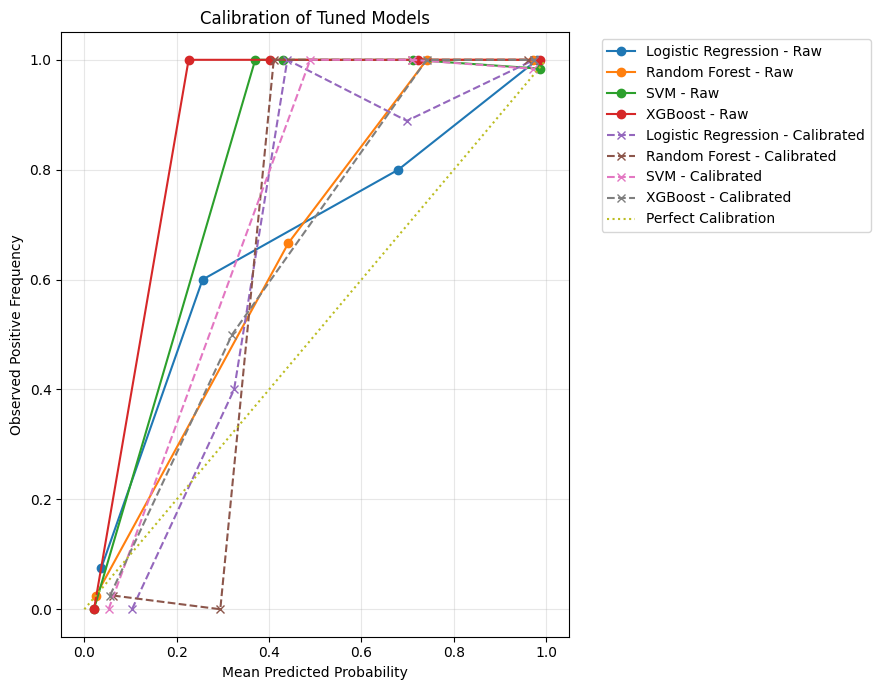

In [126]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(9, 7))

for name, search in tuned_searches.items():

    model = search.best_estimator_

    prob = model.predict_proba(X_test)[:, 1]

    fraction_positive, mean_predicted = calibration_curve(
        y_test,
        prob,
        n_bins=5,
        strategy="uniform"
    )

    plt.plot(
        mean_predicted,
        fraction_positive,
        marker="o",
        label=f"{name} - Raw"
    )

for name, model in calibrated_models.items():

    prob = model.predict_proba(X_test)[:, 1]

    fraction_positive, mean_predicted = calibration_curve(
        y_test,
        prob,
        n_bins=5,
        strategy="uniform"
    )

    plt.plot(
        mean_predicted,
        fraction_positive,
        marker="x",
        linestyle="--",
        label=f"{name} - Calibrated"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Frequency")
plt.title("Calibration of Tuned Models")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Step 73 — Generate out-of-fold probabilities for threshold selection

In [127]:
from sklearn.model_selection import cross_val_predict

threshold_oof_results = {}

for name, search in tuned_searches.items():

    print(f"Generating OOF probabilities for {name}...")

    oof_prob = cross_val_predict(
        search.best_estimator_,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=1
    )[:, 1]

    threshold_oof_results[name] = oof_prob

print("✅ Out-of-fold probabilities generated.")

Generating OOF probabilities for Logistic Regression...
Generating OOF probabilities for Random Forest...
Generating OOF probabilities for SVM...
Generating OOF probabilities for XGBoost...
✅ Out-of-fold probabilities generated.


Step 74 — Test multiple thresholds

In [128]:
thresholds = np.arange(
    0.20,
    0.81,
    0.05
)

threshold_results = []

for name, probabilities in threshold_oof_results.items():

    for threshold in thresholds:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_train,
            predictions
        ).ravel()

        specificity = tn / (tn + fp)

        threshold_results.append({
            "Model": name,
            "Threshold": threshold,
            "Accuracy": accuracy_score(
                y_train,
                predictions
            ),
            "Precision": precision_score(
                y_train,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_train,
                predictions,
                zero_division=0
            ),
            "Specificity": specificity,
            "F1": f1_score(
                y_train,
                predictions,
                zero_division=0
            )
        })

threshold_results_df = pd.DataFrame(
    threshold_results
)

threshold_results_df.head()

,Model,Threshold,Accuracy,Precision,Recall,Specificity,F1
0,Logistic Regression,0.20,0.903846,0.891304,0.960938,0.81250,0.924812
1,Logistic Regression,0.25,0.915865,0.913858,0.953125,0.85625,0.933078
2,Logistic Regression,0.30,0.927885,0.931298,0.953125,0.88750,0.942085
3,Logistic Regression,0.35,0.932692,0.945312,0.945312,0.91250,0.945312
4,Logistic Regression,0.40,0.935096,0.949020,0.945312,0.91875,0.947162


Step 75 — See how recall changes

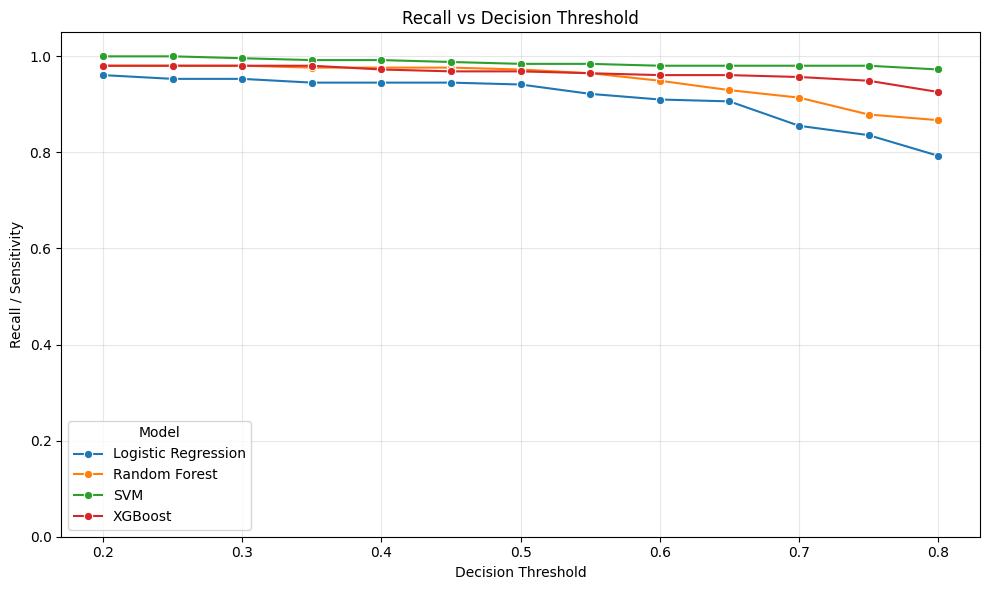

In [129]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=threshold_results_df,
    x="Threshold",
    y="Recall",
    hue="Model",
    marker="o"
)

plt.title("Recall vs Decision Threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("Recall / Sensitivity")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Step 76 — See specificity

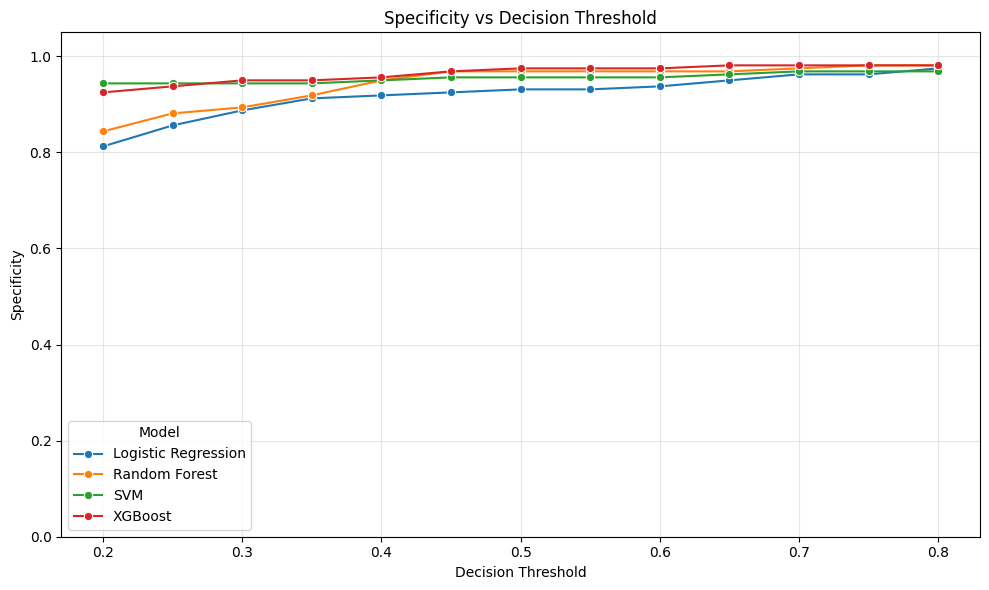

In [130]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=threshold_results_df,
    x="Threshold",
    y="Specificity",
    hue="Model",
    marker="o"
)

plt.title("Specificity vs Decision Threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("Specificity")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Step 77 — Plot F1

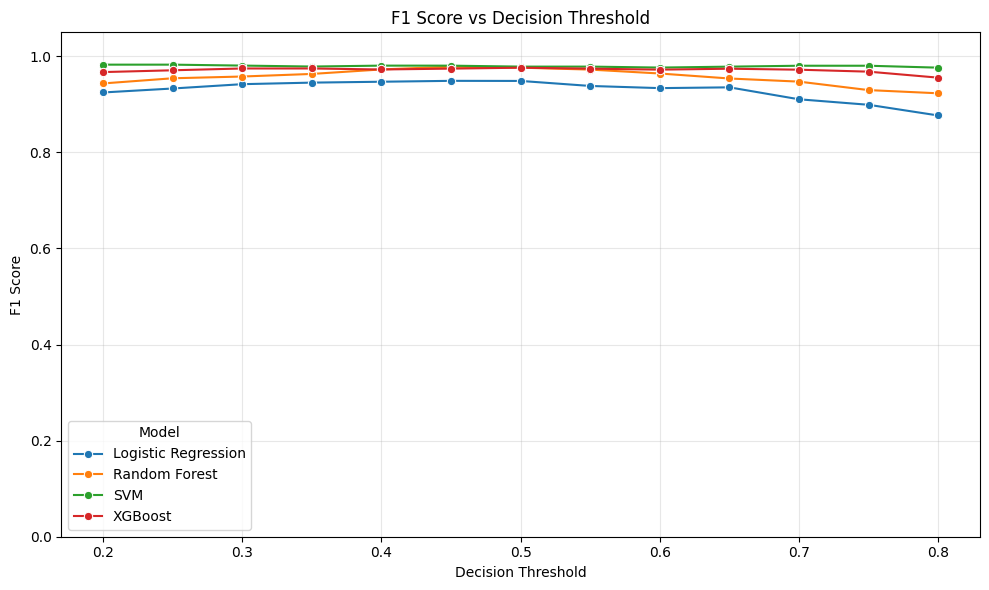

In [131]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=threshold_results_df,
    x="Threshold",
    y="F1",
    hue="Model",
    marker="o"
)

plt.title("F1 Score vs Decision Threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Step 78 — Find the threshold with maximum F1

In [132]:
best_f1_thresholds = (
    threshold_results_df
    .loc[
        threshold_results_df
        .groupby("Model")["F1"]
        .idxmax()
    ]
    .reset_index(drop=True)
)

best_f1_thresholds

,Model,Threshold,Accuracy,Precision,Recall,Specificity,F1
0,Logistic Regression,0.45,0.937500,0.952756,0.945312,0.92500,0.949020
1,Random Forest,0.45,0.973558,0.980392,0.976562,0.96875,0.978474
2,SVM,0.20,0.978365,0.966038,1.000000,0.94375,0.982726
3,XGBoost,0.50,0.971154,0.984127,0.968750,0.97500,0.976378


Step 79 — Use F2 as a recall-emphasizing analysis

In [133]:
from sklearn.metrics import fbeta_score

threshold_results_f2 = []

for name, probabilities in threshold_oof_results.items():

    for threshold in thresholds:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        f2 = fbeta_score(
            y_train,
            predictions,
            beta=2,
            zero_division=0
        )

        threshold_results_f2.append({
            "Model": name,
            "Threshold": threshold,
            "F2": f2
        })

threshold_f2_df = pd.DataFrame(
    threshold_results_f2
)

threshold_f2_df.head()

,Model,Threshold,F2
0,Logistic Regression,0.20,0.946154
1,Logistic Regression,0.25,0.945004
2,Logistic Regression,0.30,0.948678
3,Logistic Regression,0.35,0.945312
4,Logistic Regression,0.40,0.946052


In [134]:
best_f2_thresholds = (
    threshold_f2_df
    .loc[
        threshold_f2_df
        .groupby("Model")["F2"]
        .idxmax()
    ]
    .reset_index(drop=True)
)

best_f2_thresholds

,Model,Threshold,F2
0,Logistic Regression,0.30,0.948678
1,Random Forest,0.45,0.977326
2,SVM,0.20,0.993018
3,XGBoost,0.30,0.978176


Step 80 — Save threshold experiments

In [135]:
threshold_results_df.to_csv(
    "results/tables/threshold_analysis.csv",
    index=False
)

threshold_f2_df.to_csv(
    "results/tables/threshold_f2_analysis.csv",
    index=False
)

best_f1_thresholds.to_csv(
    "results/tables/best_f1_thresholds.csv",
    index=False
)

best_f2_thresholds.to_csv(
    "results/tables/best_f2_thresholds.csv",
    index=False
)

print("✅ Threshold analysis saved.")

✅ Threshold analysis saved.


Step 81 — Evaluate selected thresholds on the untouched test set

In [136]:
threshold_test_results = []

for name, search in tuned_searches.items():

    model = search.best_estimator_

    test_prob = model.predict_proba(X_test)[:, 1]

    # Threshold chosen from training OOF F1
    selected_row = best_f1_thresholds[
        best_f1_thresholds["Model"] == name
    ].iloc[0]

    threshold = selected_row["Threshold"]

    test_pred = (
        test_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        test_pred
    ).ravel()

    specificity = tn / (tn + fp)

    threshold_test_results.append({
        "Model": name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            test_pred
        ),
        "Precision": precision_score(
            y_test,
            test_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            test_pred,
            zero_division=0
        ),
        "Specificity": specificity,
        "F1": f1_score(
            y_test,
            test_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            test_prob
        )
    })

threshold_test_df = pd.DataFrame(
    threshold_test_results
)

threshold_test_df

,Model,Threshold,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC
0,Logistic Regression,0.45,0.932692,0.983051,0.90625,0.975,0.943089,0.991016
1,Random Forest,0.45,0.980769,1.000000,0.96875,1.000,0.984127,0.997656
2,SVM,0.20,0.990385,0.984615,1.00000,0.975,0.992248,0.996875
3,XGBoost,0.50,0.980769,1.000000,0.96875,1.000,0.984127,1.000000


Step 82 — Compare 0.50 vs selected threshold

In [137]:
threshold_comparison = []

for name, search in tuned_searches.items():

    model = search.best_estimator_

    test_prob = model.predict_proba(X_test)[:, 1]

    # Default threshold
    pred_50 = (
        test_prob >= 0.50
    ).astype(int)

    # Research-selected threshold
    selected_threshold = best_f1_thresholds[
        best_f1_thresholds["Model"] == name
    ].iloc[0]["Threshold"]

    pred_selected = (
        test_prob >= selected_threshold
    ).astype(int)

    threshold_comparison.append({
        "Model": name,
        "Default_Threshold": 0.50,
        "Selected_Threshold": selected_threshold,

        "Default_Recall": recall_score(
            y_test,
            pred_50,
            zero_division=0
        ),

        "Selected_Recall": recall_score(
            y_test,
            pred_selected,
            zero_division=0
        ),

        "Default_Specificity": (
            confusion_matrix(
                y_test,
                pred_50
            ).ravel()[0]
            /
            (
                confusion_matrix(
                    y_test,
                    pred_50
                ).ravel()[0]
                +
                confusion_matrix(
                    y_test,
                    pred_50
                ).ravel()[1]
            )
        ),

        "Selected_Specificity": (
            confusion_matrix(
                y_test,
                pred_selected
            ).ravel()[0]
            /
            (
                confusion_matrix(
                    y_test,
                    pred_selected
                ).ravel()[0]
                +
                confusion_matrix(
                    y_test,
                    pred_selected
                ).ravel()[1]
            )
        )
    })

threshold_comparison_df = pd.DataFrame(
    threshold_comparison
)

threshold_comparison_df

,Model,Default_Threshold,Selected_Threshold,Default_Recall,Selected_Recall,Default_Specificity,Selected_Specificity
0,Logistic Regression,0.5,0.45,0.90625,0.90625,0.975,0.975
1,Random Forest,0.5,0.45,0.96875,0.96875,1.000,1.000
2,SVM,0.5,0.20,0.96875,1.00000,0.975,0.975
3,XGBoost,0.5,0.50,0.96875,0.96875,1.000,1.000


In [138]:
threshold_test_df

,Model,Threshold,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC
0,Logistic Regression,0.45,0.932692,0.983051,0.90625,0.975,0.943089,0.991016
1,Random Forest,0.45,0.980769,1.000000,0.96875,1.000,0.984127,0.997656
2,SVM,0.20,0.990385,0.984615,1.00000,0.975,0.992248,0.996875
3,XGBoost,0.50,0.980769,1.000000,0.96875,1.000,0.984127,1.000000


In [139]:
threshold_comparison_df

,Model,Default_Threshold,Selected_Threshold,Default_Recall,Selected_Recall,Default_Specificity,Selected_Specificity
0,Logistic Regression,0.5,0.45,0.90625,0.90625,0.975,0.975
1,Random Forest,0.5,0.45,0.96875,0.96875,1.000,1.000
2,SVM,0.5,0.20,0.96875,1.00000,0.975,0.975
3,XGBoost,0.5,0.50,0.96875,0.96875,1.000,1.000


Step 83 — Start with XGBoost

In [143]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


Step 84 — Extract the tuned XGBoost pipeline

In [144]:
xgb_final_pipeline = xgb_search.best_estimator_

print(xgb_final_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                 

Step 85 — Transform the training and test data

In [145]:
xgb_preprocessor = (
    xgb_final_pipeline
    .named_steps["preprocessor"]
)

xgb_model = (
    xgb_final_pipeline
    .named_steps["model"]
)

X_train_xgb = xgb_preprocessor.transform(X_train)
X_test_xgb = xgb_preprocessor.transform(X_test)

print("Training transformed shape:", X_train_xgb.shape)
print("Testing transformed shape:", X_test_xgb.shape)

Training transformed shape: (416, 31)
Testing transformed shape: (104, 31)


Step 86 — Get feature names

In [146]:
xgb_feature_names = (
    xgb_preprocessor
    .get_feature_names_out()
)

print("Number of model features:", len(xgb_feature_names))

for i, feature in enumerate(xgb_feature_names):
    print(i, feature)

Number of model features: 31
0 numeric__age
1 categorical__gender_Female
2 categorical__gender_Male
3 categorical__polyuria_No
4 categorical__polyuria_Yes
5 categorical__polydipsia_No
6 categorical__polydipsia_Yes
7 categorical__sudden_weight_loss_No
8 categorical__sudden_weight_loss_Yes
9 categorical__weakness_No
10 categorical__weakness_Yes
11 categorical__polyphagia_No
12 categorical__polyphagia_Yes
13 categorical__genital_thrush_No
14 categorical__genital_thrush_Yes
15 categorical__visual_blurring_No
16 categorical__visual_blurring_Yes
17 categorical__itching_No
18 categorical__itching_Yes
19 categorical__irritability_No
20 categorical__irritability_Yes
21 categorical__delayed_healing_No
22 categorical__delayed_healing_Yes
23 categorical__partial_paresis_No
24 categorical__partial_paresis_Yes
25 categorical__muscle_stiffness_No
26 categorical__muscle_stiffness_Yes
27 categorical__alopecia_No
28 categorical__alopecia_Yes
29 categorical__obesity_No
30 categorical__obesity_Yes


Step 87 — Create the SHAP explainer

In [147]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(
    X_test_xgb
)

print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (104, 31)


Step 88 — SHAP summary plot

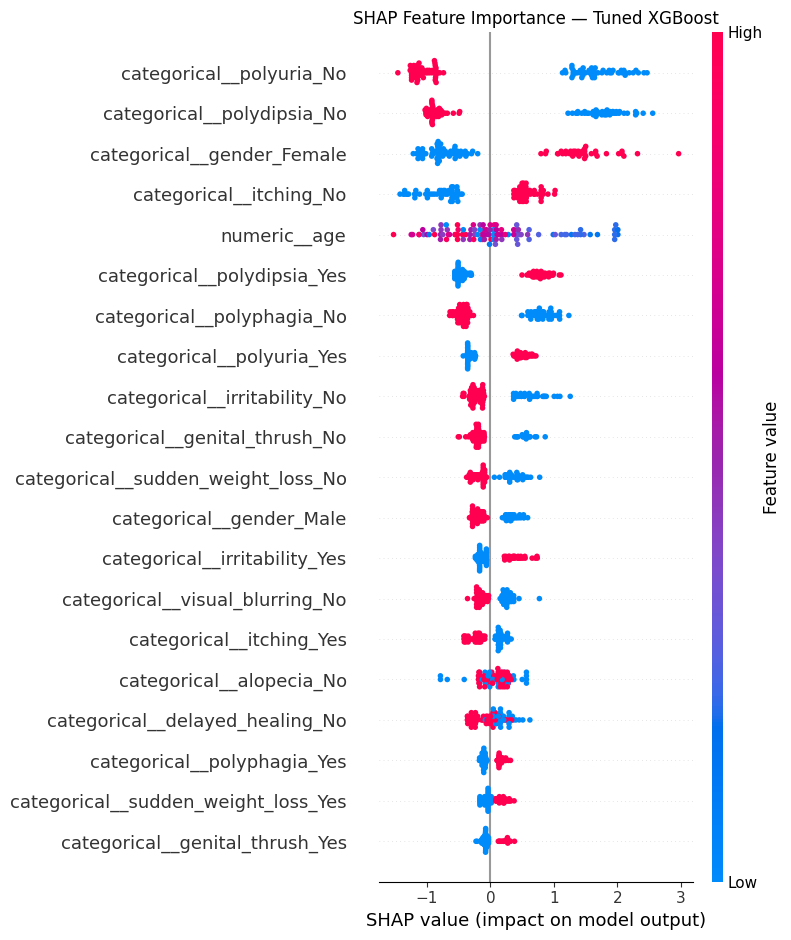

In [148]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test_xgb,
    feature_names=xgb_feature_names,
    show=False
)

plt.title("SHAP Feature Importance — Tuned XGBoost")
plt.tight_layout()
plt.show()

Step 89 — SHAP bar plot

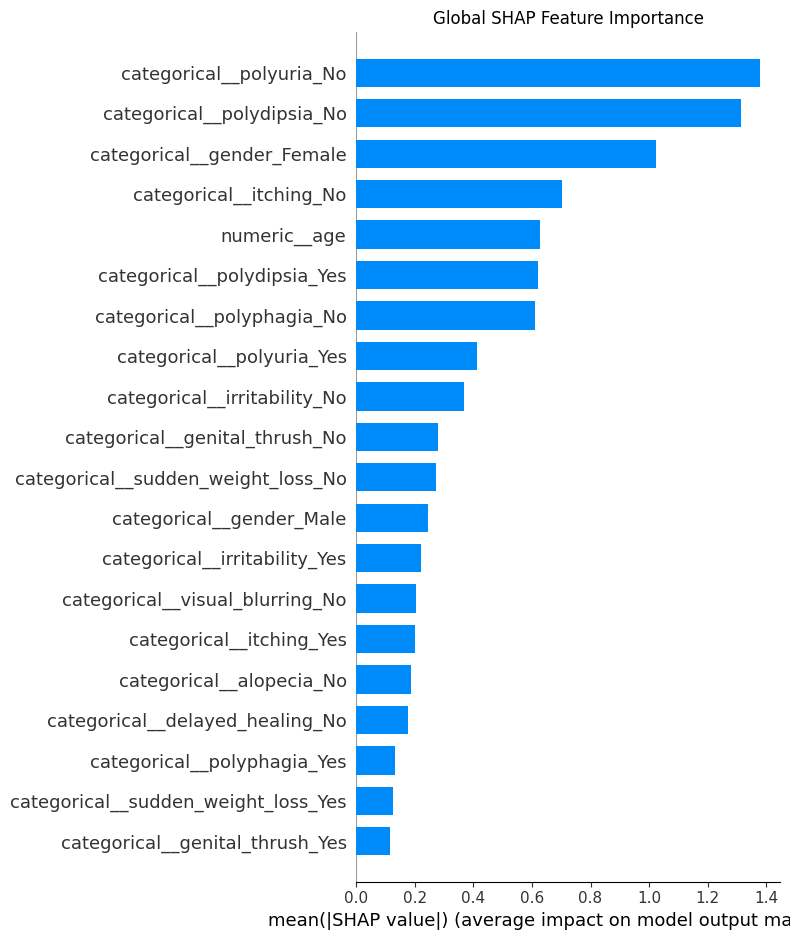

In [149]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test_xgb,
    feature_names=xgb_feature_names,
    plot_type="bar",
    show=False
)

plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.show()

Step 90 — Get numerical SHAP importance

In [150]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": xgb_feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_importance_df = (
    shap_importance_df
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance_df.head(20)

,Feature,Mean_Absolute_SHAP
0,categorical__polyuria_No,1.378355
1,categorical__polydipsia_No,1.313493
2,categorical__gender_Female,1.024571
3,categorical__itching_No,0.702861
4,numeric__age,0.628101
5,categorical__polydipsia_Yes,0.621153
6,categorical__polyphagia_No,0.611059
7,categorical__polyuria_Yes,0.411146
8,categorical__irritability_No,0.366558
9,categorical__genital_thrush_No,0.278285


Step 91 — Save SHAP importance

In [151]:
shap_importance_df.to_csv(
    "results/tables/shap_feature_importance.csv",
    index=False
)

print("✅ SHAP feature importance saved.")

✅ SHAP feature importance saved.


Step 92 — Compare SHAP with our feature-selection experiment

In [152]:
shap_importance_df.head(20)

,Feature,Mean_Absolute_SHAP
0,categorical__polyuria_No,1.378355
1,categorical__polydipsia_No,1.313493
2,categorical__gender_Female,1.024571
3,categorical__itching_No,0.702861
4,numeric__age,0.628101
5,categorical__polydipsia_Yes,0.621153
6,categorical__polyphagia_No,0.611059
7,categorical__polyuria_Yes,0.411146
8,categorical__irritability_No,0.366558
9,categorical__genital_thrush_No,0.278285


In [153]:
selected_features

['age',
 'gender',
 'polyuria',
 'polydipsia',
 'sudden_weight_loss',
 'polyphagia',
 'partial_paresis',
 'alopecia']

Step 93 — Individual patient explanation

In [154]:
patient_index = 0

patient_data = X_test_xgb[
    patient_index:patient_index + 1
]

patient_shap = shap_values[
    patient_index
]

patient_probability = (
    xgb_final_pipeline
    .predict_proba(
        X_test.iloc[[patient_index]]
    )[0, 1]
)

print("Patient probability:", patient_probability)

Patient probability: 0.016905678


Step 94 — Create the waterfall explanation

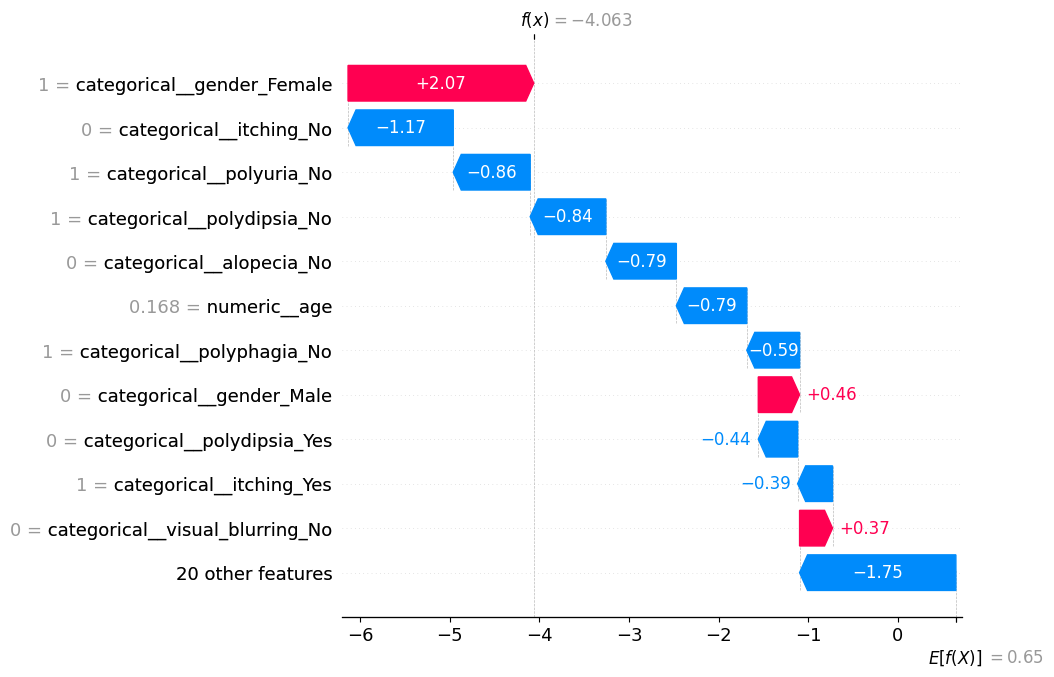

In [155]:
patient_explanation = shap.Explanation(
    values=patient_shap,
    base_values=explainer.expected_value,
    data=patient_data[0],
    feature_names=xgb_feature_names
)

shap.plots.waterfall(
    patient_explanation,
    max_display=12
)

Step 95 — Save the main SHAP figure

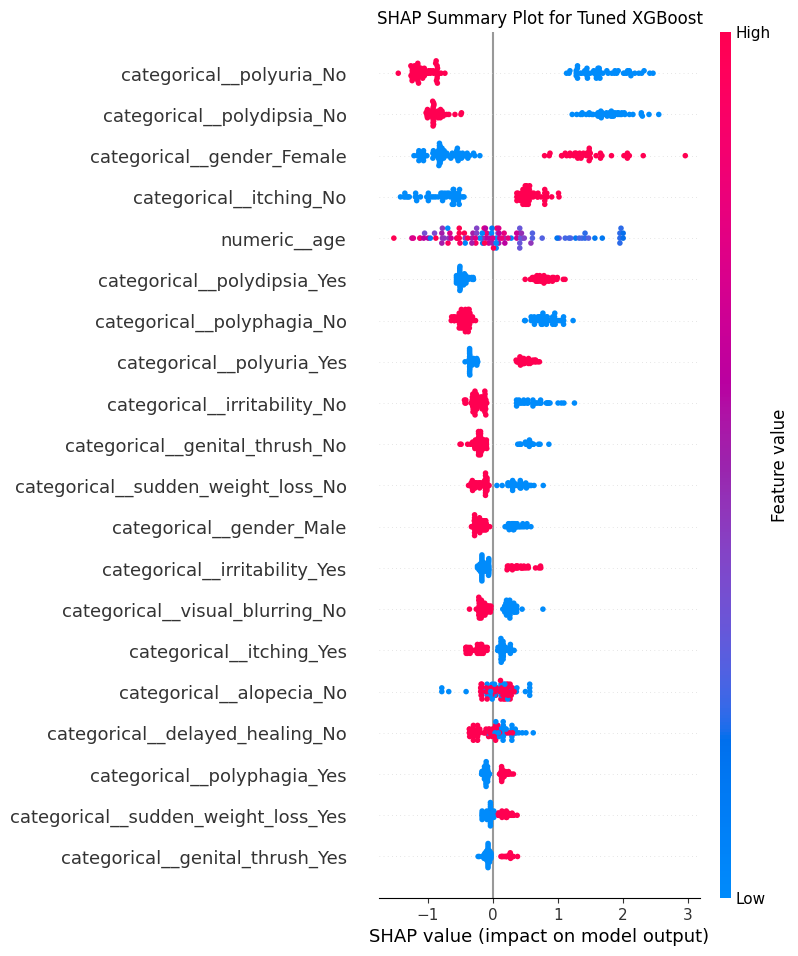

✅ SHAP figure saved.


In [156]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test_xgb,
    feature_names=xgb_feature_names,
    show=False
)

plt.title("SHAP Summary Plot for Tuned XGBoost")

plt.savefig(
    "results/figures/shap_summary_xgboost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ SHAP figure saved.")

In [157]:
shap_importance_df.head(20)

,Feature,Mean_Absolute_SHAP
0,categorical__polyuria_No,1.378355
1,categorical__polydipsia_No,1.313493
2,categorical__gender_Female,1.024571
3,categorical__itching_No,0.702861
4,numeric__age,0.628101
5,categorical__polydipsia_Yes,0.621153
6,categorical__polyphagia_No,0.611059
7,categorical__polyuria_Yes,0.411146
8,categorical__irritability_No,0.366558
9,categorical__genital_thrush_No,0.278285


Step 96 — Analyze XGBoost errors

In [159]:
xgb_test_prob = xgb_final_pipeline.predict_proba(X_test)[:, 1]

xgb_test_pred = (
    xgb_test_prob >= 0.50
).astype(int)

error_analysis_df = X_test.copy()

error_analysis_df["Actual"] = y_test.values
error_analysis_df["Predicted"] = xgb_test_pred
error_analysis_df["Probability"] = xgb_test_prob

error_analysis_df["Error_Type"] = "Correct"

error_analysis_df.loc[
    (error_analysis_df["Actual"] == 0) &
    (error_analysis_df["Predicted"] == 1),
    "Error_Type"
] = "False Positive"

error_analysis_df.loc[
    (error_analysis_df["Actual"] == 1) &
    (error_analysis_df["Predicted"] == 0),
    "Error_Type"
] = "False Negative"

error_analysis_df

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,Actual,Predicted,Probability,Error_Type
332,50,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No,0,0,0.016906,Correct
152,55,Male,No,Yes,No,Yes,No,Yes,No,No,Yes,Yes,No,No,Yes,No,1,1,0.994721,Correct
8,67,Male,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,Yes,1,1,0.998679,Correct
370,45,Male,No,No,No,No,Yes,Yes,No,No,No,No,No,No,No,No,0,0,0.045675,Correct
349,37,Male,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,0,0.027393,Correct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434,53,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,Yes,No,Yes,No,1,1,0.999920,Correct
298,39,Female,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No,No,1,1,0.999911,Correct
160,28,Female,No,No,No,No,No,No,Yes,No,No,No,Yes,Yes,No,No,1,1,0.945896,Correct
336,42,Male,No,No,No,No,No,No,No,No,No,No,No,No,Yes,No,0,0,0.040909,Correct


Step 97 — Count errors

In [160]:
error_analysis_df["Error_Type"].value_counts()

,count
Error_Type,
Correct,102
False Negative,2


Step 98 — Display false positives

In [161]:
false_positives = error_analysis_df[
    error_analysis_df["Error_Type"] == "False Positive"
]

print("Number of False Positives:", len(false_positives))

false_positives

Number of False Positives: 0


,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,Actual,Predicted,Probability,Error_Type


Step 99 — Display false negatives

In [162]:
false_negatives = error_analysis_df[
    error_analysis_df["Error_Type"] == "False Negative"
]

print("Number of False Negatives:", len(false_negatives))

false_negatives

Number of False Negatives: 2


,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,Actual,Predicted,Probability,Error_Type
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,1,0,0.225678,False Negative
123,47,Male,No,Yes,No,No,No,No,Yes,Yes,No,No,No,No,Yes,Yes,1,0,0.401019,False Negative


Step 100 — Examine prediction probabilities

In [163]:
error_cases = error_analysis_df[
    error_analysis_df["Error_Type"] != "Correct"
].copy()

error_cases[
    [
        "Actual",
        "Predicted",
        "Probability",
        "Error_Type"
    ]
].sort_values(
    "Probability"
)

,Actual,Predicted,Probability,Error_Type
1,1,0,0.225678,False Negative
123,1,0,0.401019,False Negative


Step 101 — Confusion matrix

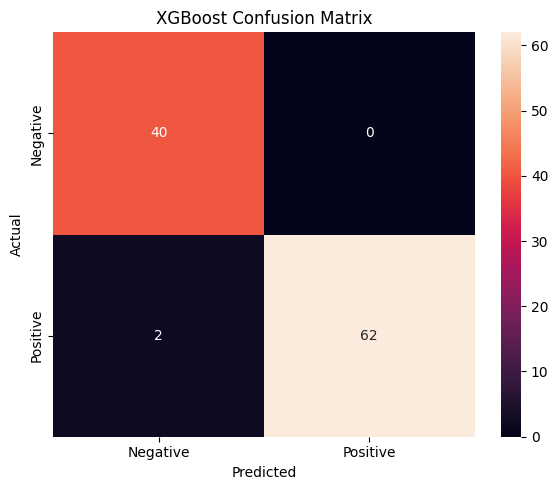

In [164]:
cm_xgb = confusion_matrix(
    y_test,
    xgb_test_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

In [165]:
plt.savefig(
    "results/figures/xgboost_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

Step 102 — Compare characteristics of correct vs incorrect cases

In [166]:
error_summary = (
    error_analysis_df
    .groupby("Error_Type")
    .agg({
        "age": ["count", "mean", "median"]
    })
)

error_summary

age                  
               count       mean median
Error_Type                            
Correct          102  48.205882   47.0
False Negative     2  52.500000   52.5

Step 103 — Analyze individual errors with SHAP

In [167]:
if len(false_negatives) > 0:
    print("False negatives available for individual SHAP analysis.")
else:
    print("No false negatives in the XGBoost test set.")

False negatives available for individual SHAP analysis.


In [168]:
if len(false_negatives) > 0:

    original_index = false_negatives.index[0]

    position = X_test.index.get_loc(
        original_index
    )

    print("Original test index:", original_index)
    print("Test position:", position)

Original test index: 1
Test position: 69


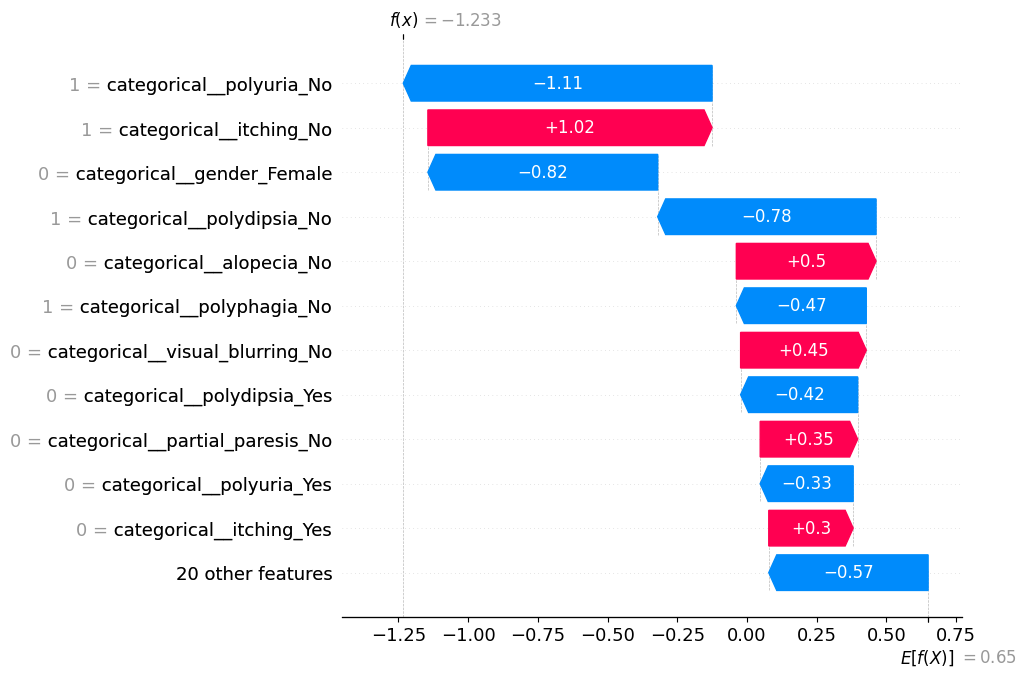

In [169]:
if len(false_negatives) > 0:

    patient_shap = shap_values[position]

    patient_data = X_test_xgb[position]

    patient_explanation = shap.Explanation(
        values=patient_shap,
        base_values=explainer.expected_value,
        data=patient_data,
        feature_names=xgb_feature_names
    )

    shap.plots.waterfall(
        patient_explanation,
        max_display=12
    )

Step 104 — Aggregate SHAP features back to original variables

In [170]:
shap_grouped = shap_importance_df.copy()

def get_original_feature(feature_name):

    if feature_name.startswith("numeric__"):
        return feature_name.replace(
            "numeric__",
            ""
        )

    if feature_name.startswith("categorical__"):
        feature_name = feature_name.replace(
            "categorical__",
            ""
        )

        parts = feature_name.rsplit("_", 1)

        if len(parts) == 2:
            return parts[0]

        return feature_name

    return feature_name

shap_grouped["Original_Feature"] = (
    shap_grouped["Feature"]
    .apply(get_original_feature)
)

shap_original_df = (
    shap_grouped
    .groupby("Original_Feature")["Mean_Absolute_SHAP"]
    .sum()
    .sort_values(
        ascending=False
    )
    .reset_index()
)

shap_original_df.head(20)

,Original_Feature,Mean_Absolute_SHAP
0,polydipsia,1.934646
1,polyuria,1.789500
2,gender,1.268530
3,itching,0.904414
4,polyphagia,0.743921
5,age,0.628101
6,irritability,0.587521
7,sudden_weight_loss,0.397342
8,genital_thrush,0.394921
9,alopecia,0.292671


Step 105 — Plot aggregated SHAP importance

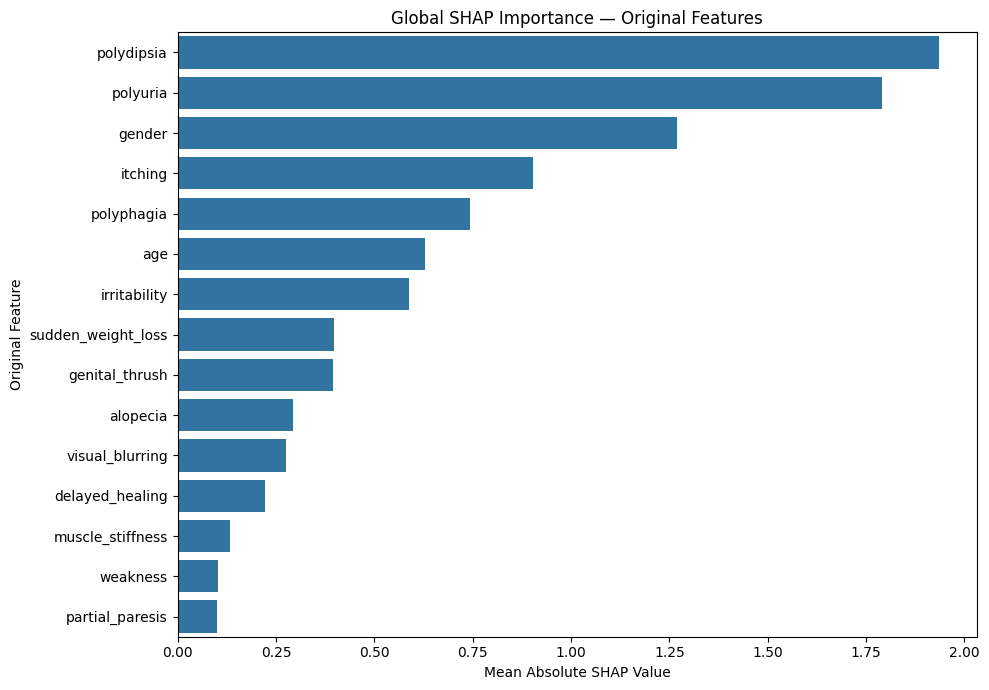

In [171]:
plt.figure(figsize=(10, 7))

top_shap = shap_original_df.head(15)

sns.barplot(
    data=top_shap,
    x="Mean_Absolute_SHAP",
    y="Original_Feature"
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Original Feature")
plt.title(
    "Global SHAP Importance — Original Features"
)

plt.tight_layout()
plt.show()

In [172]:
plt.savefig(
    "results/figures/shap_original_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

Step 106 — Compare SHAP with our selected features

In [173]:
selected_set = set(selected_features)

shap_original_df["Selected_by_MI"] = (
    shap_original_df["Original_Feature"]
    .isin(selected_set)
)

shap_original_df.head(20)

,Original_Feature,Mean_Absolute_SHAP,Selected_by_MI
0,polydipsia,1.934646,True
1,polyuria,1.789500,True
2,gender,1.268530,True
3,itching,0.904414,False
4,polyphagia,0.743921,True
5,age,0.628101,True
6,irritability,0.587521,False
7,sudden_weight_loss,0.397342,True
8,genital_thrush,0.394921,False
9,alopecia,0.292671,True


Step 107 — Save error analysis

In [174]:
error_analysis_df.to_csv(
    "results/tables/xgboost_error_analysis.csv",
    index=False
)

shap_original_df.to_csv(
    "results/tables/shap_original_feature_importance.csv",
    index=False
)

print("✅ Error analysis and aggregated SHAP results saved.")

✅ Error analysis and aggregated SHAP results saved.


Step 108 — Import repeated CV

In [175]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

robust_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

print("✅ Repeated Stratified 5-Fold CV created.")
print("Total validation runs per model:", 5 * 3)

✅ Repeated Stratified 5-Fold CV created.
Total validation runs per model: 15


Step 109 — Define the final candidate models

In [176]:
robust_models = {
    "Random Forest": rf_search.best_estimator_,
    "SVM": svm_search.best_estimator_,
    "XGBoost": xgb_search.best_estimator_
}

print("Models selected for robustness testing:")

for name in robust_models:
    print("-", name)

Models selected for robustness testing:
- Random Forest
- SVM
- XGBoost


In [177]:
rf_search.best_estimator_
svm_search.best_estimator_
xgb_search.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'polyuria...
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None,
                               learning_rate=np.float64(0.06673971219322068),
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=596, n_jobs=-1,
                               num_parallel_tree=None, ...))])

Step 110 — Run repeated cross-validation

In [178]:
robustness_results = []

scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

for name, model in robust_models.items():

    print(f"\nRunning robustness test: {name}")

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=robust_cv,
        scoring=scoring_metrics,
        n_jobs=1,
        return_train_score=False
    )

    robustness_results.append({
        "Model": name,

        "Accuracy_Mean": scores["test_accuracy"].mean(),
        "Accuracy_STD": scores["test_accuracy"].std(),

        "Precision_Mean": scores["test_precision"].mean(),
        "Precision_STD": scores["test_precision"].std(),

        "Recall_Mean": scores["test_recall"].mean(),
        "Recall_STD": scores["test_recall"].std(),

        "F1_Mean": scores["test_f1"].mean(),
        "F1_STD": scores["test_f1"].std(),

        "ROC_AUC_Mean": scores["test_roc_auc"].mean(),
        "ROC_AUC_STD": scores["test_roc_auc"].std()
    })

    print(f"✅ Completed: {name}")


Running robustness test: Random Forest
✅ Completed: Random Forest

Running robustness test: SVM
✅ Completed: SVM

Running robustness test: XGBoost
✅ Completed: XGBoost


Step 111 — Create the robustness table

In [179]:
robustness_df = pd.DataFrame(
    robustness_results
)

robustness_df

,Model,Accuracy_Mean,Accuracy_STD,Precision_Mean,Precision_STD,Recall_Mean,Recall_STD,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD
0,Random Forest,0.961580,0.025099,0.978774,0.013255,0.958472,0.036471,0.968165,0.021294,0.986985,0.009264
1,SVM,0.970396,0.017365,0.973246,0.017709,0.979236,0.023848,0.975980,0.014363,0.994955,0.006387
2,XGBoost,0.969554,0.022305,0.982787,0.014210,0.967471,0.027243,0.974926,0.018553,0.990445,0.009266


In [180]:
robustness_df.style.format({
    "Accuracy_Mean": "{:.4f}",
    "Accuracy_STD": "{:.4f}",
    "Precision_Mean": "{:.4f}",
    "Precision_STD": "{:.4f}",
    "Recall_Mean": "{:.4f}",
    "Recall_STD": "{:.4f}",
    "F1_Mean": "{:.4f}",
    "F1_STD": "{:.4f}",
    "ROC_AUC_Mean": "{:.4f}",
    "ROC_AUC_STD": "{:.4f}"
})

,Model,Accuracy_Mean,Accuracy_STD,Precision_Mean,Precision_STD,Recall_Mean,Recall_STD,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD
0,Random Forest,0.9616,0.0251,0.9788,0.0133,0.9585,0.0365,0.9682,0.0213,0.9870,0.0093
1,SVM,0.9704,0.0174,0.9732,0.0177,0.9792,0.0238,0.9760,0.0144,0.9950,0.0064
2,XGBoost,0.9696,0.0223,0.9828,0.0142,0.9675,0.0272,0.9749,0.0186,0.9904,0.0093


Step 112 — Save robustness results

In [181]:
robustness_df.to_csv(
    "results/tables/robustness_results.csv",
    index=False
)

print("✅ Robustness results saved.")

✅ Robustness results saved.


Step 113 — Visualize robustness

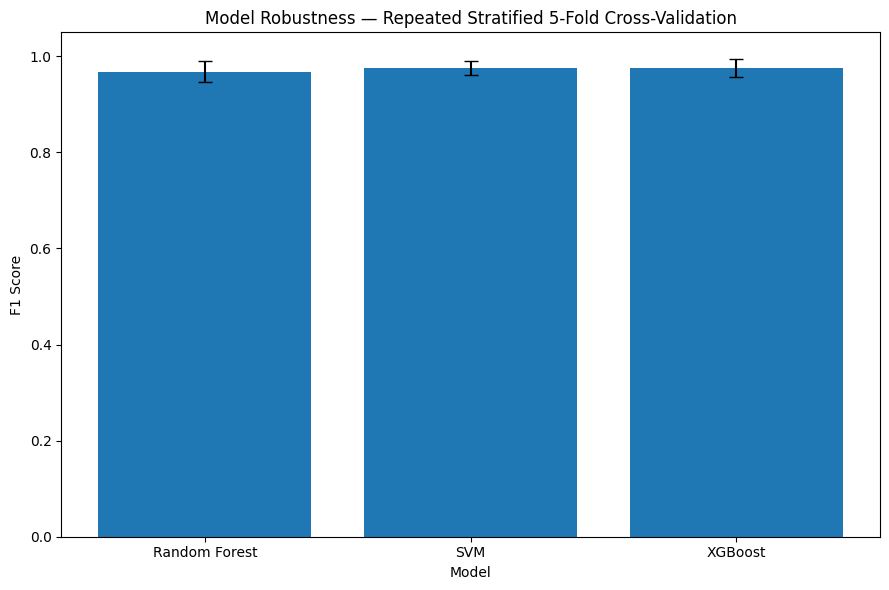

In [182]:
plt.figure(figsize=(9, 6))

plt.bar(
    robustness_df["Model"],
    robustness_df["F1_Mean"],
    yerr=robustness_df["F1_STD"],
    capsize=5
)

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title(
    "Model Robustness — Repeated Stratified 5-Fold Cross-Validation"
)

plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [183]:
plt.savefig(
    "results/figures/robustness_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

Step 114 — Inspect the variability

In [184]:
robustness_df[
    [
        "Model",
        "Recall_Mean",
        "Recall_STD",
        "F1_Mean",
        "F1_STD",
        "ROC_AUC_Mean",
        "ROC_AUC_STD"
    ]
]

,Model,Recall_Mean,Recall_STD,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD
0,Random Forest,0.958472,0.036471,0.968165,0.021294,0.986985,0.009264
1,SVM,0.979236,0.023848,0.975980,0.014363,0.994955,0.006387
2,XGBoost,0.967471,0.027243,0.974926,0.018553,0.990445,0.009266


Step 115 — Create a compact research table

In [185]:
final_robustness_table = robustness_df[
    [
        "Model",
        "Accuracy_Mean",
        "Accuracy_STD",
        "Recall_Mean",
        "Recall_STD",
        "F1_Mean",
        "F1_STD",
        "ROC_AUC_Mean",
        "ROC_AUC_STD"
    ]
].copy()

final_robustness_table

,Model,Accuracy_Mean,Accuracy_STD,Recall_Mean,Recall_STD,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD
0,Random Forest,0.961580,0.025099,0.958472,0.036471,0.968165,0.021294,0.986985,0.009264
1,SVM,0.970396,0.017365,0.979236,0.023848,0.975980,0.014363,0.994955,0.006387
2,XGBoost,0.969554,0.022305,0.967471,0.027243,0.974926,0.018553,0.990445,0.009266


In [186]:
final_robustness_table.columns = [
    "Model",
    "Accuracy Mean",
    "Accuracy SD",
    "Recall Mean",
    "Recall SD",
    "F1 Mean",
    "F1 SD",
    "ROC-AUC Mean",
    "ROC-AUC SD"
]

final_robustness_table

,Model,Accuracy Mean,Accuracy SD,Recall Mean,Recall SD,F1 Mean,F1 SD,ROC-AUC Mean,ROC-AUC SD
0,Random Forest,0.961580,0.025099,0.958472,0.036471,0.968165,0.021294,0.986985,0.009264
1,SVM,0.970396,0.017365,0.979236,0.023848,0.975980,0.014363,0.994955,0.006387
2,XGBoost,0.969554,0.022305,0.967471,0.027243,0.974926,0.018553,0.990445,0.009266


Step 116 — Check for suspicious performance

In [187]:
for name, model in robust_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=robust_cv,
        scoring="f1",
        n_jobs=1,
        return_train_score=False
    )

    print("\n", name)
    print("F1 scores:")
    print(np.round(scores["test_score"], 4))

    print(
        "Mean:",
        round(scores["test_score"].mean(), 4)
    )

    print(
        "STD:",
        round(scores["test_score"].std(), 4)
    )

    print(
        "Minimum:",
        round(scores["test_score"].min(), 4)
    )

    print(
        "Maximum:",
        round(scores["test_score"].max(), 4)
    )


 Random Forest
F1 scores:
[1.     0.9903 0.9505 0.9608 0.98   0.94   0.9808 0.9703 0.96   0.96
 0.9184 0.9703 0.9608 0.9804 1.    ]
Mean: 0.9682
STD: 0.0213
Minimum: 0.9184
Maximum: 1.0

 SVM
F1 scores:
[0.972  0.9804 0.9608 0.9804 0.9901 0.9714 1.     0.9808 0.9709 0.9703
 0.94   0.9808 0.9615 0.9903 0.9901]
Mean: 0.976
STD: 0.0144
Minimum: 0.94
Maximum: 1.0

 XGBoost
F1 scores:
[1.     0.9804 0.9608 0.9495 0.9901 0.9709 0.9901 0.9804 0.9709 0.96
 0.9505 0.9903 0.94   1.     0.9901]
Mean: 0.9749
STD: 0.0186
Minimum: 0.94
Maximum: 1.0


Step 117 — Basic dataset audit

In [188]:
print("TRAIN SHAPE:", X_train.shape)
print("TEST SHAPE :", X_test.shape)

print("\nTarget distribution — TRAIN:")
print(y_train.value_counts())

print("\nTarget distribution — TEST:")
print(y_test.value_counts())

print("\nTarget proportions — TRAIN:")
print(y_train.value_counts(normalize=True))

print("\nTarget proportions — TEST:")
print(y_test.value_counts(normalize=True))

TRAIN SHAPE: (416, 16)
TEST SHAPE : (104, 16)

Target distribution — TRAIN:
class
1    256
0    160
Name: count, dtype: int64

Target distribution — TEST:
class
1    64
0    40
Name: count, dtype: int64

Target proportions — TRAIN:
class
1    0.615385
0    0.384615
Name: proportion, dtype: float64

Target proportions — TEST:
class
1    0.615385
0    0.384615
Name: proportion, dtype: float64


Step 118 — Check duplicate rows

In [189]:
print("Duplicate rows in X_train:", X_train.duplicated().sum())
print("Duplicate rows in X_test :", X_test.duplicated().sum())

print(
    "Duplicate rows in complete dataset:",
    pd.concat([X_train, X_test]).duplicated().sum()
)

Duplicate rows in X_train: 197
Duplicate rows in X_test : 16
Duplicate rows in complete dataset: 269


Step 119 — Check train/test overlap

In [190]:
train_rows = X_train.astype(str).agg(
    "|".join,
    axis=1
)

test_rows = X_test.astype(str).agg(
    "|".join,
    axis=1
)

overlap = set(train_rows).intersection(
    set(test_rows)
)

print("Exact train/test duplicate rows:", len(overlap))

Exact train/test duplicate rows: 56


Step 120 — Check duplicate rows with conflicting targets

In [191]:
full_audit_df = pd.concat(
    [
        X_train.assign(_target=y_train.values),
        X_test.assign(_target=y_test.values)
    ],
    ignore_index=True
)

duplicate_target_check = (
    full_audit_df
    .groupby(
        list(X_train.columns),
        dropna=False
    )["_target"]
    .nunique()
)

conflicting_duplicates = (
    duplicate_target_check[
        duplicate_target_check > 1
    ]
)

print(
    "Duplicate feature patterns with conflicting targets:",
    len(conflicting_duplicates)
)

Duplicate feature patterns with conflicting targets: 0


Step 121 — Check whether target accidentally exists in features

In [192]:
print("Target variable type:", y_train.dtype)

print("\nFeatures containing target-like names:")

target_like_columns = [
    col for col in X_train.columns
    if any(
        word in col.lower()
        for word in [
            "target",
            "label",
            "class",
            "outcome",
            "diagnosis",
            "result"
        ]
    )
]

print(target_like_columns)

Target variable type: int64

Features containing target-like names:
[]


Step 122 — Check constant features

In [193]:
constant_features = [
    col
    for col in X_train.columns
    if X_train[col].nunique(dropna=False) <= 1
]

print("Constant features:")
print(constant_features)

print(
    "Number of constant features:",
    len(constant_features)
)

Constant features:
[]
Number of constant features: 0


Step 123 — Check duplicate columns

In [194]:
duplicate_columns = []

columns = X_train.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):

        col1 = columns[i]
        col2 = columns[j]

        if X_train[col1].equals(X_train[col2]):
            duplicate_columns.append(
                (col1, col2)
            )

print("Duplicate column pairs:")
print(duplicate_columns)

Duplicate column pairs:
[]


Step 124 — Check whether any feature exactly matches the target

In [195]:
exact_target_matches = []

for col in X_train.columns:

    feature = X_train[col]

    try:
        if feature.reset_index(drop=True).equals(
            y_train.reset_index(drop=True)
        ):
            exact_target_matches.append(col)
    except:
        pass

print("Features exactly matching target:")
print(exact_target_matches)

Features exactly matching target:
[]


Step 125 — Check categorical feature distributions

In [196]:
categorical_columns = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Categorical features:")
print(categorical_columns)

Categorical features:
['gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity']


In [197]:
for col in categorical_columns:

    print("\n" + "=" * 60)
    print("FEATURE:", col)

    print(
        pd.crosstab(
            X_train[col],
            y_train,
            normalize="index"
        ).round(3)
    )


FEATURE: gender
class       0      1
gender              
Female  0.097  0.903
Male    0.553  0.447

FEATURE: polyuria
class         0      1
polyuria              
No        0.695  0.305
Yes       0.068  0.932

FEATURE: polydipsia
class           0      1
polydipsia              
No          0.657  0.343
Yes         0.038  0.962

FEATURE: sudden_weight_loss
class                   0      1
sudden_weight_loss              
No                  0.569  0.431
Yes                 0.136  0.864

FEATURE: weakness
class         0      1
weakness              
No        0.515  0.485
Yes       0.297  0.703

FEATURE: polyphagia
class           0      1
polyphagia              
No          0.531  0.469
Yes         0.214  0.786

FEATURE: genital_thrush
class               0      1
genital_thrush              
No              0.408  0.592
Yes             0.305  0.695

FEATURE: visual_blurring
class                0      1
visual_blurring              
No               0.491  0.509
Yes              

Step 126 — Numerical feature audit

In [198]:
numeric_columns = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print("Numeric features:")
print(numeric_columns)

if len(numeric_columns) > 0:

    numeric_summary = X_train[numeric_columns].describe().T

    numeric_summary

Numeric features:
['age']


Step 127 — Check missing values

In [199]:
missing_train = X_train.isnull().sum()
missing_test = X_test.isnull().sum()

missing_summary = pd.DataFrame({
    "Train_Missing": missing_train,
    "Test_Missing": missing_test
})

missing_summary[
    (missing_summary["Train_Missing"] > 0) |
    (missing_summary["Test_Missing"] > 0)
]

,Train_Missing,Test_Missing


Step 128 — Generate a single audit summary

In [200]:
audit_summary = pd.DataFrame({
    "Check": [
        "Train rows",
        "Test rows",
        "Train features",
        "Test features",
        "Duplicate rows in train",
        "Duplicate rows in test",
        "Train/Test exact overlap",
        "Conflicting duplicate targets",
        "Constant features",
        "Duplicate column pairs",
        "Exact target-matching features"
    ],

    "Result": [
        len(X_train),
        len(X_test),
        X_train.shape[1],
        X_test.shape[1],
        X_train.duplicated().sum(),
        X_test.duplicated().sum(),
        len(overlap),
        len(conflicting_duplicates),
        len(constant_features),
        len(duplicate_columns),
        len(exact_target_matches)
    ]
})

audit_summary

,Check,Result
0,Train rows,416
1,Test rows,104
2,Train features,16
3,Test features,16
4,Duplicate rows in train,197
5,Duplicate rows in test,16
6,Train/Test exact overlap,56
7,Conflicting duplicate targets,0
8,Constant features,0
9,Duplicate column pairs,0


In [201]:
audit_summary.to_csv(
    "results/tables/data_leakage_audit.csv",
    index=False
)

print("✅ Data leakage audit saved.")

✅ Data leakage audit saved.


In [202]:
audit_summary

,Check,Result
0,Train rows,416
1,Test rows,104
2,Train features,16
3,Test features,16
4,Duplicate rows in train,197
5,Duplicate rows in test,16
6,Train/Test exact overlap,56
7,Conflicting duplicate targets,0
8,Constant features,0
9,Duplicate column pairs,0


Step 129 — Create the final evidence table

In [203]:
final_candidates = robustness_df[
    [
        "Model",
        "Accuracy_Mean",
        "Accuracy_STD",
        "Recall_Mean",
        "Recall_STD",
        "F1_Mean",
        "F1_STD",
        "ROC_AUC_Mean",
        "ROC_AUC_STD"
    ]
].copy()

final_candidates

,Model,Accuracy_Mean,Accuracy_STD,Recall_Mean,Recall_STD,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD
0,Random Forest,0.961580,0.025099,0.958472,0.036471,0.968165,0.021294,0.986985,0.009264
1,SVM,0.970396,0.017365,0.979236,0.023848,0.975980,0.014363,0.994955,0.006387
2,XGBoost,0.969554,0.022305,0.967471,0.027243,0.974926,0.018553,0.990445,0.009266


Step 130 — Add the final test performance

In [204]:
final_candidates = final_candidates.merge(
    tuned_test_results_df[
        [
            "Model",
            "Accuracy",
            "Recall",
            "Specificity",
            "F1",
            "ROC-AUC",
            "PR-AUC",
            "Brier Score"
        ]
    ],
    on="Model",
    how="left",
    suffixes=("_CV", "_Test")
)

final_candidates

,Model,Accuracy_Mean,Accuracy_STD,Recall_Mean,Recall_STD,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD,Accuracy,Recall,Specificity,F1,ROC-AUC,PR-AUC,Brier Score
0,Random Forest,0.961580,0.025099,0.958472,0.036471,0.968165,0.021294,0.986985,0.009264,0.980769,0.96875,1.000,0.984127,0.997656,0.998661,0.020764
1,SVM,0.970396,0.017365,0.979236,0.023848,0.975980,0.014363,0.994955,0.006387,0.971154,0.96875,0.975,0.976378,0.996875,0.997965,0.017583
2,XGBoost,0.969554,0.022305,0.967471,0.027243,0.974926,0.018553,0.990445,0.009266,0.980769,0.96875,1.000,0.984127,1.000000,1.000000,0.011451


Step 131 — Add threshold information

In [205]:
final_candidates = final_candidates.merge(
    threshold_test_df[
        [
            "Model",
            "Threshold",
            "Precision",
            "Recall",
            "Specificity",
            "F1"
        ]
    ],
    on="Model",
    how="left",
    suffixes=("", "_Threshold")
)

final_candidates

,Model,Accuracy_Mean,Accuracy_STD,Recall_Mean,Recall_STD,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD,Accuracy,...,Specificity,F1,ROC-AUC,PR-AUC,Brier Score,Threshold,Precision,Recall_Threshold,Specificity_Threshold,F1_Threshold
0,Random Forest,0.961580,0.025099,0.958472,0.036471,0.968165,0.021294,0.986985,0.009264,0.980769,...,1.000,0.984127,0.997656,0.998661,0.020764,0.45,1.000000,0.96875,1.000,0.984127
1,SVM,0.970396,0.017365,0.979236,0.023848,0.975980,0.014363,0.994955,0.006387,0.971154,...,0.975,0.976378,0.996875,0.997965,0.017583,0.20,0.984615,1.00000,0.975,0.992248
2,XGBoost,0.969554,0.022305,0.967471,0.027243,0.974926,0.018553,0.990445,0.009266,0.980769,...,1.000,0.984127,1.000000,1.000000,0.011451,0.50,1.000000,0.96875,1.000,0.984127


Step 132 — Format the final evidence table

In [206]:
final_candidates.style.format({
    "Accuracy_Mean": "{:.4f}",
    "Accuracy_STD": "{:.4f}",
    "Recall_Mean": "{:.4f}",
    "Recall_STD": "{:.4f}",
    "F1_Mean": "{:.4f}",
    "F1_STD": "{:.4f}",
    "ROC_AUC_Mean": "{:.4f}",
    "ROC_AUC_STD": "{:.4f}",
    "Accuracy": "{:.4f}",
    "Recall": "{:.4f}",
    "Specificity": "{:.4f}",
    "F1": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}",
    "Brier Score": "{:.4f}",
    "Threshold": "{:.2f}",
    "Precision": "{:.4f}"
})

,Model,Accuracy_Mean,Accuracy_STD,Recall_Mean,Recall_STD,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD,Accuracy,Recall,Specificity,F1,ROC-AUC,PR-AUC,Brier Score,Threshold,Precision,Recall_Threshold,Specificity_Threshold,F1_Threshold
0,Random Forest,0.9616,0.0251,0.9585,0.0365,0.9682,0.0213,0.9870,0.0093,0.9808,0.9688,1.0000,0.9841,0.9977,0.9987,0.0208,0.45,1.0000,0.968750,1.000000,0.984127
1,SVM,0.9704,0.0174,0.9792,0.0238,0.9760,0.0144,0.9950,0.0064,0.9712,0.9688,0.9750,0.9764,0.9969,0.9980,0.0176,0.20,0.9846,1.000000,0.975000,0.992248
2,XGBoost,0.9696,0.0223,0.9675,0.0272,0.9749,0.0186,0.9904,0.0093,0.9808,0.9688,1.0000,0.9841,1.0000,1.0000,0.0115,0.50,1.0000,0.968750,1.000000,0.984127


Step 133 — Save the complete evidence

In [207]:
final_candidates.to_csv(
    "results/tables/final_model_evidence.csv",
    index=False
)

print("✅ Final model evidence saved.")

✅ Final model evidence saved.


Step 134 — Create a transparent selection score

In [208]:
selection_table = robustness_df.copy()

selection_table = selection_table.sort_values(
    by=[
        "F1_Mean",
        "Recall_Mean",
        "F1_STD",
        "ROC_AUC_Mean"
    ],
    ascending=[
        False,
        False,
        True,
        False
    ]
).reset_index(drop=True)

selection_table

,Model,Accuracy_Mean,Accuracy_STD,Precision_Mean,Precision_STD,Recall_Mean,Recall_STD,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD
0,SVM,0.970396,0.017365,0.973246,0.017709,0.979236,0.023848,0.975980,0.014363,0.994955,0.006387
1,XGBoost,0.969554,0.022305,0.982787,0.014210,0.967471,0.027243,0.974926,0.018553,0.990445,0.009266
2,Random Forest,0.961580,0.025099,0.978774,0.013255,0.958472,0.036471,0.968165,0.021294,0.986985,0.009264


Step 135 — Check calibration before locking

In [209]:
calibrated_results_df[
    [
        "Model",
        "Recall",
        "Specificity",
        "F1",
        "ROC-AUC",
        "Brier Score"
    ]
]

,Model,Recall,Specificity,F1,ROC-AUC,Brier Score
0,Logistic Regression,0.906250,0.975,0.943089,0.990625,0.047249
1,Random Forest,0.968750,1.000,0.984127,0.995313,0.017593
2,SVM,0.984375,0.975,0.984375,0.997656,0.016779
3,XGBoost,0.968750,1.000,0.984127,0.999219,0.015028


In [210]:
brier_comparison

,Model,Uncalibrated_Brier,Calibrated_Brier,Change
0,Logistic Regression,0.049747,0.047249,-0.002498
1,Random Forest,0.020764,0.017593,-0.003172
2,SVM,0.017583,0.016779,-0.000804
3,XGBoost,0.011451,0.015028,0.003577


Step 136 — Check the leakage audit

In [211]:
audit_summary

,Check,Result
0,Train rows,416
1,Test rows,104
2,Train features,16
3,Test features,16
4,Duplicate rows in train,197
5,Duplicate rows in test,16
6,Train/Test exact overlap,56
7,Conflicting duplicate targets,0
8,Constant features,0
9,Duplicate column pairs,0


Step 137 — Lock the selected model

In [212]:
final_model_name = selection_table.iloc[0]["Model"]

print("Selected final model configuration:")
print(final_model_name)

Selected final model configuration:
SVM


In [213]:
final_search = tuned_searches[
    final_model_name
]

final_pipeline = final_search.best_estimator_

print(final_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                 

Step 138 — Retrain final pipeline

In [214]:
final_pipeline.fit(
    X_train,
    y_train
)

print("✅ Final model trained on complete training set.")

✅ Final model trained on complete training set.


Step 139 — Final untouched test evaluation

In [215]:
final_test_probability = (
    final_pipeline
    .predict_proba(X_test)[:, 1]
)

final_test_prediction = (
    final_test_probability >= 0.50
).astype(int)

final_metrics = calculate_metrics(
    y_test,
    final_test_prediction,
    final_test_probability
)

final_metrics

{'Accuracy': 0.9711538461538461,
 'Precision': 0.9841269841269841,
 'Recall': 0.96875,
 'Specificity': np.float64(0.975),
 'F1': 0.9763779527559056,
 'ROC-AUC': np.float64(0.9968750000000001),
 'PR-AUC': np.float64(0.9979646514897182),
 'Brier Score': np.float64(0.017582987596735825)}

Step 140 — Save the final model

In [216]:
import joblib
from pathlib import Path

Path("models").mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    final_pipeline,
    "models/final_healthcare_model.joblib"
)

print(
    "✅ Final model saved to "
    "models/final_healthcare_model.joblib"
)

✅ Final model saved to models/final_healthcare_model.joblib


Step 141 — Save the final metadata

In [217]:
final_metadata = {
    "model_name": final_model_name,
    "threshold": 0.50,
    "features": list(X_train.columns),
    "metrics": final_metrics
}

joblib.dump(
    final_metadata,
    "models/final_model_metadata.joblib"
)

print("✅ Model metadata saved.")

✅ Model metadata saved.


In [218]:
final_model_name

'SVM'

In [219]:
final_metrics

{'Accuracy': 0.9711538461538461,
 'Precision': 0.9841269841269841,
 'Recall': 0.96875,
 'Specificity': np.float64(0.975),
 'F1': 0.9763779527559056,
 'ROC-AUC': np.float64(0.9968750000000001),
 'PR-AUC': np.float64(0.9979646514897182),
 'Brier Score': np.float64(0.017582987596735825)}

In [220]:
final_candidates

,Model,Accuracy_Mean,Accuracy_STD,Recall_Mean,Recall_STD,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD,Accuracy,...,Specificity,F1,ROC-AUC,PR-AUC,Brier Score,Threshold,Precision,Recall_Threshold,Specificity_Threshold,F1_Threshold
0,Random Forest,0.961580,0.025099,0.958472,0.036471,0.968165,0.021294,0.986985,0.009264,0.980769,...,1.000,0.984127,0.997656,0.998661,0.020764,0.45,1.000000,0.96875,1.000,0.984127
1,SVM,0.970396,0.017365,0.979236,0.023848,0.975980,0.014363,0.994955,0.006387,0.971154,...,0.975,0.976378,0.996875,0.997965,0.017583,0.20,0.984615,1.00000,0.975,0.992248
2,XGBoost,0.969554,0.022305,0.967471,0.027243,0.974926,0.018553,0.990445,0.009266,0.980769,...,1.000,0.984127,1.000000,1.000000,0.011451,0.50,1.000000,0.96875,1.000,0.984127


Step 142 — First verify the exact input columns

In [221]:
print("FINAL INPUT FEATURES:")
for i, col in enumerate(X_train.columns, 1):
    print(f"{i}. {col}")

FINAL INPUT FEATURES:
1. age
2. gender
3. polyuria
4. polydipsia
5. sudden_weight_loss
6. weakness
7. polyphagia
8. genital_thrush
9. visual_blurring
10. itching
11. irritability
12. delayed_healing
13. partial_paresis
14. muscle_stiffness
15. alopecia
16. obesity


Step 143 — Verify the saved SVM

In [222]:
import joblib

final_pipeline = joblib.load(
    "models/final_healthcare_model.joblib"
)

print(final_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                 

Step 144 — Test one complete prediction

In [223]:
sample_patient = X_test.iloc[[0]].copy()

sample_probability = final_pipeline.predict_proba(
    sample_patient
)[0, 1]

sample_prediction = final_pipeline.predict(
    sample_patient
)[0]

print("Prediction:", sample_prediction)
print("Probability:", round(sample_probability, 4))

Prediction: 0
Probability: 0.0245


Step 145 — Create the Streamlit app

In [224]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib


# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="AI Smart Healthcare",
    page_icon="🩺",
    layout="wide"
)


# --------------------------------------------------
# LOAD MODEL
# --------------------------------------------------

@st.cache_resource
def load_model():

    model = joblib.load(
        "models/final_healthcare_model.joblib"
    )

    return model


model = load_model()


# --------------------------------------------------
# TITLE
# --------------------------------------------------

st.title("🩺 AI Smart Healthcare")
st.subheader("Early Disease Risk Prediction")

st.write(
    """
    Enter the available patient information below.
    The trained machine-learning model will generate
    an estimated prediction based on the provided inputs.
    """
)


# --------------------------------------------------
# INPUT FORM
# --------------------------------------------------

with st.form("patient_form"):

    st.header("Patient Information")

    age = st.number_input(
        "Age",
        min_value=1,
        max_value=120,
        value=30
    )

    gender = st.selectbox(
        "Gender",
        ["Male", "Female"]
    )

    col1, col2 = st.columns(2)

    with col1:

        polyuria = st.selectbox(
            "Polyuria",
            ["Yes", "No"]
        )

        polydipsia = st.selectbox(
            "Polydipsia",
            ["Yes", "No"]
        )

        sudden_weight_loss = st.selectbox(
            "Sudden Weight Loss",
            ["Yes", "No"]
        )

        weakness = st.selectbox(
            "Weakness",
            ["Yes", "No"]
        )

        polyphagia = st.selectbox(
            "Polyphagia",
            ["Yes", "No"]
        )

        genital_thrush = st.selectbox(
            "Genital Thrush",
            ["Yes", "No"]
        )

        visual_blurring = st.selectbox(
            "Visual Blurring",
            ["Yes", "No"]
        )

        itching = st.selectbox(
            "Itching",
            ["Yes", "No"]
        )

    with col2:

        irritability = st.selectbox(
            "Irritability",
            ["Yes", "No"]
        )

        delayed_healing = st.selectbox(
            "Delayed Healing",
            ["Yes", "No"]
        )

        partial_paresis = st.selectbox(
            "Partial Paresis",
            ["Yes", "No"]
        )

        muscle_stiffness = st.selectbox(
            "Muscle Stiffness",
            ["Yes", "No"]
        )

        alopecia = st.selectbox(
            "Alopecia",
            ["Yes", "No"]
        )

        obesity = st.selectbox(
            "Obesity",
            ["Yes", "No"]
        )

    submitted = st.form_submit_button(
        "🔍 Predict Risk"
    )


# --------------------------------------------------
# PREDICTION
# --------------------------------------------------

if submitted:

    patient = pd.DataFrame([{
        "age": age,
        "gender": gender,
        "polyuria": polyuria,
        "polydipsia": polydipsia,
        "sudden_weight_loss": sudden_weight_loss,
        "weakness": weakness,
        "polyphagia": polyphagia,
        "genital_thrush": genital_thrush,
        "visual_blurring": visual_blurring,
        "itching": itching,
        "irritability": irritability,
        "delayed_healing": delayed_healing,
        "partial_paresis": partial_paresis,
        "muscle_stiffness": muscle_stiffness,
        "alopecia": alopecia,
        "obesity": obesity
    }])

    probability = model.predict_proba(
        patient
    )[0, 1]

    prediction = model.predict(
        patient
    )[0]


    # --------------------------------------------------
    # RESULT
    # --------------------------------------------------

    st.divider()

    st.header("Prediction Result")

    probability_percentage = probability * 100

    if prediction == 1:

        st.error(
            f"⚠️ Model Prediction: Positive"
        )

        st.metric(
            "Estimated Positive Probability",
            f"{probability_percentage:.2f}%"
        )

    else:

        st.success(
            f"✅ Model Prediction: Negative"
        )

        st.metric(
            "Estimated Positive Probability",
            f"{probability_percentage:.2f}%"
        )


# --------------------------------------------------
# DISCLAIMER
# --------------------------------------------------

st.divider()

st.warning(
    """
    **Research Prototype — Not a Medical Diagnosis**

    This application is an academic machine-learning
    prototype developed for research and educational purposes.
    Its prediction should not be used as a substitute for
    professional medical examination, diagnosis, or treatment.
    """
)

Writing app.py


Step 146 — Check the app file

In [225]:
!ls -lh app.py

-rw-r--r-- 1 root root 4.8K Sep 26 19:47 app.py


Step 147 — Install Streamlit

In [226]:
!pip -q install streamlit

Step 148 — Check the model files

In [227]:
!find models -maxdepth 2 -type f

models/final_model_metadata.joblib
models/.gitkeep
models/final_healthcare_model.joblib


In [228]:
print(X_train.columns.tolist())

['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity']


Step 149 — Print the complete feature list clearly

In [229]:
print("FINAL FEATURES")
print("=" * 40)

for i, col in enumerate(X_train.columns, 1):
    print(f"{i}. {col}")

FINAL FEATURES
1. age
2. gender
3. polyuria
4. polydipsia
5. sudden_weight_loss
6. weakness
7. polyphagia
8. genital_thrush
9. visual_blurring
10. itching
11. irritability
12. delayed_healing
13. partial_paresis
14. muscle_stiffness
15. alopecia
16. obesity


Step 150 — Automatically verify the Streamlit input columns

In [230]:
expected_features = [
    "age",
    "gender",
    "polyuria",
    "polydipsia",
    "sudden_weight_loss",
    "weakness",
    "polyphagia",
    "genital_thrush",
    "visual_blurring",
    "itching",
    "irritability",
    "delayed_healing",
    "partial_paresis",
    "muscle_stiffness",
    "alopecia",
    "obesity"
]

actual_features = X_train.columns.tolist()

print("Expected:", expected_features)
print("\nActual:", actual_features)

print("\nMissing from expected:")
print(set(expected_features) - set(actual_features))

print("\nUnexpected:")
print(set(actual_features) - set(expected_features))

Expected: ['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity']

Actual: ['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity']

Missing from expected:
set()

Unexpected:
set()


Step 151 — Verify the saved SVM independently

In [231]:
import joblib

loaded_model = joblib.load(
    "models/final_healthcare_model.joblib"
)

print("Loaded model successfully.")
print(loaded_model)

Loaded model successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                      

In [232]:
test_patient = X_test.iloc[[0]].copy()

prediction = loaded_model.predict(test_patient)[0]
probability = loaded_model.predict_proba(
    test_patient
)[0, 1]

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: 0
Probability: 0.024470312070468247


Step 152 — Check app.py

In [233]:
!ls -lh app.py

-rw-r--r-- 1 root root 4.8K Sep 26 19:47 app.py


In [234]:
!head -30 app.py


import streamlit as st
import pandas as pd
import joblib


# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="AI Smart Healthcare",
    page_icon="🩺",
    layout="wide"
)


# --------------------------------------------------
# LOAD MODEL
# --------------------------------------------------

@st.cache_resource
def load_model():

    model = joblib.load(
        "models/final_healthcare_model.joblib"
    )

    return model



Step 153 — Replace the entire cell with this

In [237]:
# Use the exact columns from the training data
X_train_columns = X_train.columns.tolist()

print("Model input columns:")
for i, col in enumerate(X_train_columns, 1):
    print(f"{i}. {col}")

Model input columns:
1. age
2. gender
3. polyuria
4. polydipsia
5. sudden_weight_loss
6. weakness
7. polyphagia
8. genital_thrush
9. visual_blurring
10. itching
11. irritability
12. delayed_healing
13. partial_paresis
14. muscle_stiffness
15. alopecia
16. obesity


Step 154 — Test the saved model properly

In [238]:
import joblib

loaded_model = joblib.load(
    "models/final_healthcare_model.joblib"
)

# Take one real test example
test_patient = X_test.iloc[[0]].copy()

# Make sure column order is exactly the same
test_patient = test_patient[X_train_columns]

prediction = loaded_model.predict(test_patient)[0]

probability = loaded_model.predict_proba(
    test_patient
)[0, 1]

print("Prediction:", prediction)
print("Positive probability:", round(probability, 4))
print("Positive probability (%):", round(probability * 100, 2), "%")

Prediction: 0
Positive probability: 0.0245
Positive probability (%): 2.45 %


Step 155 — Verify the app file

In [257]:
!ls -lh app.py

-rw-r--r-- 1 root root 4.8K Sep 26 19:47 app.py


In [259]:
!python -m py_compile app.py

Step 156 — Test the deployed Streamlit app

Step 157 — Get the reference patient

In [260]:
test_patient = X_test.iloc[[0]].copy()

display(test_patient)

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity
332,50,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No


Step 158 — Get the reference prediction

In [261]:
reference_prediction = loaded_model.predict(
    test_patient
)[0]

reference_probability = loaded_model.predict_proba(
    test_patient
)[0, 1]

print("Reference prediction:", reference_prediction)
print(
    "Reference probability:",
    round(reference_probability * 100, 2),
    "%"
)

Reference prediction: 0
Reference probability: 2.45 %


Step 159 — Enter that patient into Streamlit

In [262]:
display(test_patient)

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity
332,50,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No


Step 160 — End-to-end verification

Step 161 — Improve the Streamlit application

Step 162 — Add model explanation
We'll integrate your existing SHAP analysis into the application so the project isn't just:
"Enter symptoms → get prediction."

Instead:
"Enter symptoms → prediction → probability → factors contributing to the model output."

This is much more appropriate for the research-project angle.
Step 163 — Final research results
We'll create the final publication-quality:
- Model comparison table
- Cross-validation table
- ROC curve
- Precision-recall curve
- Confusion matrix
- Calibration plot
- Feature importance / SHAP plot
- Threshold analysis
- Error analysis
- Robustness results
We won't invent any numbers. We'll use the actual results you've generated.
Step 164 — Research paper
Then we'll structure the paper as:
1. Abstract
2. Introduction
3. Related Work
4. Problem Statement
5. Dataset
6. Methodology
7. Data Preprocessing
8. Feature Selection
9. Model Development
10. Hyperparameter Optimization
11. Threshold Optimization
12. Explainability
13. Experimental Results
14. Error Analysis
15. Discussion
16. Limitations
17. Conclusion
18. Future Work
19. References

Step 165 — Project report
Then we'll create your MCA project report.
Step 166 — PPT
We'll turn the actual research into your presentation.
Step 167 — Viva
I'll prepare:
- 30-second explanation
- 2-minute explanation
- 5-minute explanation
- 30+ technical questions
- Research questions
- "Why SVM?"
- "Why this dataset?"
- "What is your novelty?"
- "What is your contribution?"
- "What are limitations?"
- "Why SHAP?"
- "Why threshold optimization?"
- "How did you prevent leakage?"
Step 168 — Final GitHub package
Final structure:
AI-Smart-Healthcare/
│
├── app.py
├── requirements.txt
├── README.md
│
├── models/
│   ├── final_healthcare_model.joblib
│   └── final_model_metadata.joblib
│
├── notebooks/
│   └── AI_Smart_Healthcare.ipynb
│
├── results/
│   ├── figures/
│   └── tables/
│
└── docs/
    ├── research-paper.pdf
    ├── project-report.pdf
    └── presentation.pptx

So right now:

In [256]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print("Streamlit URL:")
print(url)

Streamlit URL:
https://8501-m-s-kkb-use1c2-2263klcv9vg2u-c.us-east1-2.prod.colab.dev


In [263]:
!ls -lh models/

total 40K
-rw-r--r-- 1 root root 35K Sep 26 19:45 final_healthcare_model.joblib
-rw-r--r-- 1 root root 587 Sep 26 19:45 final_model_metadata.joblib


In [265]:
files.download("models/final_model_metadata.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>